---
# <div align="center"><font color='blue'> COSC 2779/2972 | Deep Learning </font></div>
## <div align="center"><font color='blue'> Assignment 2: Deep Learning Project - Sequence Modelling</font></div>
### <div align="center">by Daniil Pkhakadze (s4101606) RMIT semester 2 2026</div>
---

## The problem.
Litmus Pty Ltd is a company that runs lessons aimed at teaching young school students about the effect of memes and how they can persuade a person.
The way it was always handled was: a company representative physically sat in a classroom at school and analyzed every meme that a student has brought in for them and then named every technique used in the picture.
However, the state's education department liked what Litmus was doing and now wants to make running this program mandatory in all schools across the state, starting from the next term. Due to the sheer scale of the program they want these sessions to be run remotely by teachers using recorded material.
<br>
This implies that now the software has to do the analysis and reading that the company representative used to do. A student will upload a meme to a specific folder on a specific website, and a certain tool will output the persuasion technique that that meme is using and pinpoint exactly where it appears.
<br><br>
Luckily there is an existing image text extractor software that is able to take the text from any meme and give it to us. For this task, we only need to work with the extracted text and not the images that contain it.
There are two parts to this task:

1. **A** (detector) - given the text extracted from the meme, output what persuasion techniques it uses. Since there can be multple techniques in one meme (or zero), this is a **multi-label** classification problem. The input to this task would be a singular image and an output would be a set of labels (containing 0 or more labels).
2. **B** (pinpointing) - for each of the techniques that were identified in the text, find the exact part of the text that uses it. This is **multi-label sequence tagging**, meaning same words can belong to 1+ technique at the same time.

<br>
The list of techniques published by the company contains 22 distinct techniques, however the dataset only covers 20 in the text with two of them missing, which means the model will only be ever be able to predict the 20 that are present.
<br>
There are some constraints for these tasks:

1. **Privacy** - the school students are minors, meaning nothing a student enters is able to ever leave the device. Hosted model APIs and third party inference services are NOT allowed due to that. Pretrained weights can however be downloaded and run locally on the device.
2. **Hardware** - the tool will be running on a machine at school with hardware not stronger than an NVIDIA Tesla T4 (16GB VRAM). It will also have to output an aswer in reasonable time, since the class will be waiting for a response. Model needs to be small enough to be quick enough to work in real-time.
3. **No shortcut checkpoints** - nothing that was trained on persuasion, propaganda or rhetoric labelled data is allowed, but pretrained text encoders are OK and allowed to be fine-tuned.
4. **Only neural networks, no classical ML** - can't use SVMs, random forests, linear regression etc. in the final system. Also cannot employ regex and keyword lists for the final decisions.

<br>
The data provided is SemEval-2021 Task 6 corpus (Dimitrov et al., 2021), which is a limited dataset - only a couple hundred memes which are annotated specifically against the taxonomy (the 22 labels). This dataset was also not collected in Australia, is not particularly recent and is not from teenagers, which is the relevant age group for the program.
<br>
After the development we will have to evaluate how good the results are specifically for use in a High School classroom in 2026, which will be covered in part **C**, where we will have to evaluate the system as a whole as a product including whether there is any bias towards either political side (C1), how well it compares to a general puspose zero-shot model (C2) and whether the label that was output and the span of text it is supposedly present in agree with each other (C3), as well as the final conclusion of whether this will be successfull in an Australian classroom (C4).

## Setup.

First, import all the necessary core libraries as usual and set the random seed to ensure reproducibility of the results.
We'll follow wk8 and 9 setup: use PyTorch for models + Hugging Face `transformers` and `peft` for the pretrained text encoders and LoRA.

In [1]:
# %pip install -q transformers peft # uncomment if there is an issue when running on AWS, since i'm developing locally on an RTX 2080 Super 8GB VRAM.

import random
import numpy as np
import torch
import transformers
import peft

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'torch {torch.__version__} | transformers {transformers.__version__} | peft {peft.__version__}')

Using device: cuda
GPU: NVIDIA GeForce RTX 2080 SUPER
torch 2.13.0+cu130 | transformers 5.18.0 | peft 0.21.2


# **Part A** - Detector

## Step 1. Loading the dataset.
The data given to us are 6 JSON files, split into SemEval training, as well as dev and test sets.
Each of the splits contains two files:

- `task1` are the files containing the text of each meme + list of techniques that it employs (for part A)
- `task2` are the files containing the same memes, but each of the listed techniques comes with specified character positions (from `start` to `end`) for each technique, which appear in the text (for part B)

We also should load the provided list of the 22 labels from the file containing the necessary taxonomy, so we cross-check data against it to see which techniques are and are not present in the data.
<br>
We will load everything into a pandas df - 1 row per meme with a dedicated column stating which split it is from.

In [2]:
import os
import pandas as pd

DATA_FOLDER = 'data'

with open('techniques_list_task3.txt', encoding='utf-8') as f:
    ALL_TECHNIQUES = f.read().strip().split('\n')

split_dfs = []
for split in ['training', 'dev', 'test']:
    task1 = pd.read_json(os.path.join(DATA_FOLDER, f'{split}_set_task1.txt'), dtype={'id': str}, encoding='utf-8')
    task2 = pd.read_json(os.path.join(DATA_FOLDER, f'{split}_set_task2.txt'), dtype={'id': str}, encoding='utf-8')

    task2 = task2.rename(columns={'labels': 'spans'})
    task2 = task2[['id', 'spans']]

    merged = task1.merge(task2, on='id', how='left')
    merged['split'] = split
    split_dfs.append(merged)

df = pd.concat(split_dfs, ignore_index=True)

print(f'Techniques in the taxonomy: {len(ALL_TECHNIQUES)}')
print(f'Total memes: {len(df)}')
df.head()

Techniques in the taxonomy: 22
Total memes: 951


,id,labels,text,spans,split
0,128,[Black-and-white Fallacy/Dictatorship],THERE ARE ONLY TWO GENDERS\n\nFEMALE \n\nMALE\n,"[{'start': 0, 'end': 41, 'technique': 'Black-a...",training
1,189,[],This is not an accident!,[],training
2,96,"[Loaded Language, Name calling/Labeling, Sloga...",SO BERNIE BROS HAVEN'T COMMITTED VIOLENCE EH?\...,"[{'end': 83, 'start': 47, 'technique': 'Slogan...",training
3,154,"[Causal Oversimplification, Loaded Language, N...",PATHETIC\n\nThe Cowardly Asshole\nWeak Failure...,"[{'end': 8, 'start': 0, 'technique': 'Loaded L...",training
4,15,[],WHO TRUMP REPRESENTS\n\nWHO DEMOCRATS REPRESENT\n,[],training


Each row of the dataframe is a single meme like we wanted.
`labels` contains the techniques for each meme and `spans` are the same techniques with specified start and end character positions for them in the text
<br>
Few things that are obvious:

- Text contains line breaks (to show meme layout maybe) and potentially other special chracters. Lots of it is capital text, which is typical of memes.
- Evidently, some memes don't contain any techniques whatsoever (id 189, id 15 for example). Specifically id 15 has text "WHO TRUMP REPRESENTS\n\nWHO DEMOCRATS REPRESENT\n" which makes me, a human, assume that this is something like persuasive propaganda for either the left or the right side or against both sides. Since we only have the text from the image and not the image itself it could be difficult to get techniques for memes, where the persuasion is carried by the contents of the actual picture. In these situation the purely text model lacks the actual context and will be unable to output correct labels, which is a big limitation.
- As expected, some memes have multiple techniques (id 96 for example).

## Step 2. Exploratory Data Analysis (EDA).

Before inspecting each technique in detail, we should make sure the data was loaded correctly. We will look at how many memes are in each split, as well as checking if every meme has the span annotations included and whether the techniques that appear in `labels` are consistent with the ones that appear in `spans` for each meme.
It is crucial that those 2 are consistent with each other, otherwise, Part A and B will have disagreements since they potentially would be learning from different labels for the same meme.

In [3]:
print('Memes per split:')
print(df['split'].value_counts())
print(f'\nMemes missing span annotations: {df["spans"].isna().sum()}')

mismatches = 0
for i in range(len(df)):
    labels = set(df['labels'][i])

    span_techniques = set()
    for span in df['spans'][i]:
        span_techniques.add(span['technique'])

    if labels != span_techniques:
        mismatches += 1

print(f'Memes where labels and spans disagree: {mismatches}')

Memes per split:
split
training    688
test        200
dev          63
Name: count, dtype: int64

Memes missing span annotations: 0
Memes where labels and spans disagree: 0


Data loaded correctly. In total there are 668 memes in the train set, 63 in dev and 200 in test. Adding up to 951 total.
Each meme present in `task1` is also present in `task2`, so no issues there. For memes with 0 techniques the span list is empty and not missing, which is what we want.
<br>
For every meme, each technique that is present in `labels` is also present present in `spans`, meaning Part A and B will correctly be learning from the same truth without disagreements. A technique is never listed for a meme without having a span of text that pointsat it.

### Technique distribution

Now we will move on to actual EDA and actually exploring the data we are presented with. We will only be inspecting train and dev sets, NOT the test set. The test set will be left aside and not touched until it is needed for the final evaluation to make sure nothing that we see in it influences our decisions, which would be biased.

As we know, each meme may contain from 0 to multiple techniques, so we have to count every technique across all the label lists for each meme. This will help us see which 2 techniques from the taxonomy never appear in the actual data.


Technique counts (train + dev, 751 memes):
  Loaded Language: 389
  Name calling/Labeling: 247
  Smears: 218
  Exaggeration/Minimisation: 59
  Doubt: 56
  Slogans: 47
  Appeal to fear/prejudice: 47
  Whataboutism: 44
  Glittering generalities (Virtue): 33
  Flag-waving: 32
  Causal Oversimplification: 28
  Misrepresentation of Someone's Position (Straw Man): 23
  Thought-terminating cliché: 21
  Black-and-white Fallacy/Dictatorship: 18
  Appeal to authority: 15
  Repetition: 11
  Reductio ad hitlerum: 10
  Obfuscation, Intentional vagueness, Confusion: 4
  Bandwagon: 4
  Presenting Irrelevant Data (Red Herring): 1

Techniques that appear: 20 of 22
Largest/smallest: 389/1 = 389x
Missing from dataset: ['Transfer', 'Appeal to (Strong) Emotions']


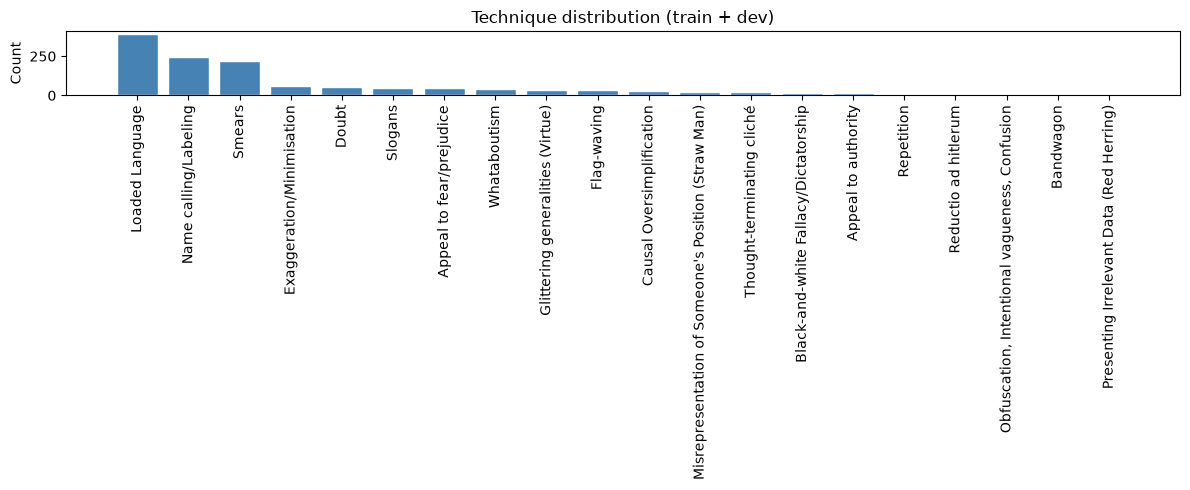

In [4]:
from collections import Counter
import matplotlib.pyplot as plt

trainval_df = df[df['split'] != 'test']

technique_counts = Counter()
for labels in trainval_df['labels']:
    technique_counts.update(labels)

names = []
values = []
print(f'Technique counts (train + dev, {len(trainval_df)} memes):')
for technique, count in technique_counts.most_common():
    print(f'  {technique}: {count}')
    names.append(technique)
    values.append(count)

print(f'\nTechniques that appear: {len(technique_counts)} of {len(ALL_TECHNIQUES)}')
print(f'Largest/smallest: {max(values)}/{min(values)} = {max(values)/min(values):.0f}x')

missing = []
for technique in ALL_TECHNIQUES:
    if technique not in technique_counts:
        missing.append(technique)
print(f'Missing from dataset: {missing}')

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(names, values, color='steelblue', edgecolor='white')
ax.set_title('Technique distribution (train + dev)')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

In [5]:
print(f'Total technique labels: {sum(values)}')

Total technique labels: 1307


The imbalance here is very extreme and a lot worse than assignment 1.
The majority class is `Loaded Language` which appears in a staggering 389 memes out of 751 total, which is >50%.
There are 1307 technique labels in total and the top 3 techniques (`Loaded Language`, `Name calling/Labeling` and `Smears`) make up around 2/3 of all technique labels (854/1307).
After these three majority classes, the counts drop off significantly - 4th most common label is `Exaggeration/Minimisation`, which only appears in 59 memes (#3, which is `Smears` appears in 218 memes)
15 our of the 20 techniques that are present in the dataset appear in <50 memes, while the bottom 3 are almost absent (`Presenting Irrelevant Data (Red Herring)` - 1, `Bandwagon` - 4, `Obfuscation, Intentional vagueness, Confusion` - 4).
The huge 389x max to min ratio appears due to the singular Red Herring meme, but even if we consider `Bandwagon` instead as the min class, the ratio is still close to 100x.
<br>
This will definitely have consequences for the chosen approach.

- **Loss** - if we use regular binary cross-entropy, then the rarely appearing techniques will contribute nearly nothing to the loss, meaning the model can do well by simple predicting the 3 majority classes. To compensate for that we need to weight the loss using the counts (per-technique positive weight) and compare it against the unweighted loss.
- **Performance measure** - if we score all the predictions together in a single pile, the top 3 common techniques will be the ones deciding most of the performance score and a model that only ever predicts the 3 can still get good performance results. We will need to score each technique separately and average in order to give each technique equal weights. Macro-F1 seems like a good choice.
- **Expectations** - a technique that is only ever seen in 1 or 4 memes likely cannot be learned from the text alone (without the attached image) with so few examples. It is reasonable to expect a near-zero score on those 3 least common techniques and report them honestly.

The two missing techniques not present in the data (train and dev) are `Transfer` and `Appeal to (Strong) Emotions`, so the model will only be outputting the 20 techniques that are present in the data.
This will be a limitation of the model, since if a student uploads a meme that uses either of the two techniques, they will never see these techniques output for it.

### Checking techniques per meme

It would be valuable for us to see how many techniques does each meme have in it. It is important, because:

- It shows how many memes there are with no techniques at all - which the model should also be able to predict, since nothing is a valid answer
- The number of labels per meme also shows how much do the techniques overlap, which is exactly what makes this a multi-label problem

We'll also be comparing dev and train sets to make sure they are similar.

Memes with 0 techniques: 158 of 751 (21.0%)
Average techniques per meme: train 1.72, dev 1.95


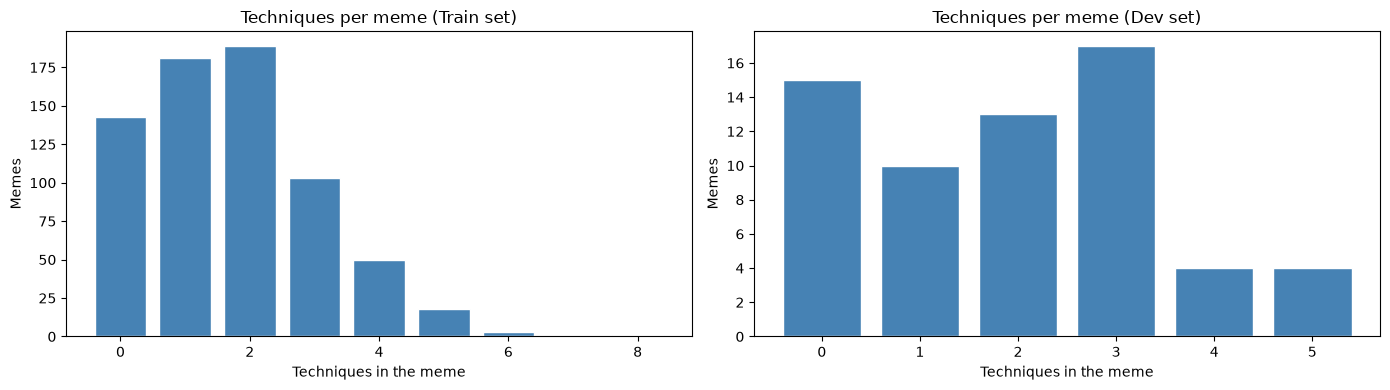

In [6]:
train_n = []
for labels in trainval_df[trainval_df['split'] == 'training']['labels']:
    train_n.append(len(labels))

dev_n = []
for labels in trainval_df[trainval_df['split'] == 'dev']['labels']:
    dev_n.append(len(labels))

all_n = train_n + dev_n
zero_count = all_n.count(0)
zero_percent = 100 * zero_count / len(all_n)
print(f'Memes with 0 techniques: {zero_count} of {len(all_n)} ({zero_percent:.1f}%)')
print(f'Average techniques per meme: train {np.mean(train_n):.2f}, dev {np.mean(dev_n):.2f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, n_list, title in zip(axes, [train_n, dev_n], ['Train', 'Dev']):
    counts = Counter(n_list)
    ax.bar(sorted(counts), [counts[k] for k in sorted(counts)], color='steelblue', edgecolor='white')
    ax.set_title(f'Techniques per meme ({title} set)')
    ax.set_xlabel('Techniques in the meme')
    ax.set_ylabel('Memes')
plt.tight_layout()
plt.show()

In [7]:
train_counts = Counter(train_n)
print('Training memes by number of techniques:')
for n in sorted(train_counts):
    print(f'  {n} techniques: {train_counts[n]} memes')

Training memes by number of techniques:
  0 techniques: 143 memes
  1 techniques: 181 memes
  2 techniques: 189 memes
  3 techniques: 103 memes
  4 techniques: 50 memes
  5 techniques: 18 memes
  6 techniques: 3 memes
  8 techniques: 1 memes


Looking at the results, 158/751 memes have 0 techniques, which is significant but still very much the minority. Most memes do have one or more techniques present in them. Also, evidently, having 2+ techniques is common and normal - more than half the dataset has 2+ techniques for each meme. In fact, there are more memes with 2 techniques than memes with 1 technique.
There are some outlier memes: 3 have 6 techniques in them and 1 has 8 techniques in it.
<br>
This further solidifies that the task is multi-label. We cannot create a regular multi-class classfication model here, since that would be an incorrect design for most memes, since they have either 0 or 2+ techniques.
<br>
The dev set looks a little different and has a slightly higher technique average than train (1.95 dev vs 1.72 train). Since dev consists only of around 60 memes, a few memes moving across the bars due to random distribution changes the shape of the graph significantly, but can be written off as noise. This may signify that the dev set is a little small to rely on it alone.

### Techniques appearing together

Since majority memes have multiple technqiues, it would be valuable to analyze which techniques tend to appear together.
We'll look at each pair of techniques and find out the conditional probability: given that a meme has a specific technique X, what percentage of those also has technique Y.
This way we will know if the model can sometimes rely on predicting a technique if the one that appears with it often is there too.
However rows for the very rare techniques will be based on very few memes (for example `Presenting Irrelevant Data (Red Herring)` appears in a singular meme), so those percentages should be ignored.

We'll do a confusion matrix display, but fill it with the conditional probabilities, since it's a very convenient way to show this data.

Most common partner for each technique:
  Loaded Language (389 memes): Name calling/Labeling 48%
  Name calling/Labeling (247 memes): Loaded Language 76%
  Smears (218 memes): Loaded Language 61%
  Exaggeration/Minimisation (59 memes): Loaded Language 51%
  Doubt (56 memes): Loaded Language 54%
  Slogans (47 memes): Loaded Language 53%
  Appeal to fear/prejudice (47 memes): Loaded Language 72%
  Whataboutism (44 memes): Loaded Language 75%
  Glittering generalities (Virtue) (33 memes): Loaded Language 48%
  Flag-waving (32 memes): Loaded Language 59%
  Causal Oversimplification (28 memes): Loaded Language 61%
  Misrepresentation of Someone's Position (Straw Man) (23 memes): Loaded Language 83%
  Thought-terminating cliché (21 memes): Loaded Language 52%
  Black-and-white Fallacy/Dictatorship (18 memes): Loaded Language 39%
  Appeal to authority (15 memes): Loaded Language 47%
  Repetition (11 memes): Loaded Language 45%
  Reductio ad hitlerum (10 memes): Loaded Language 70%
  Obfuscati

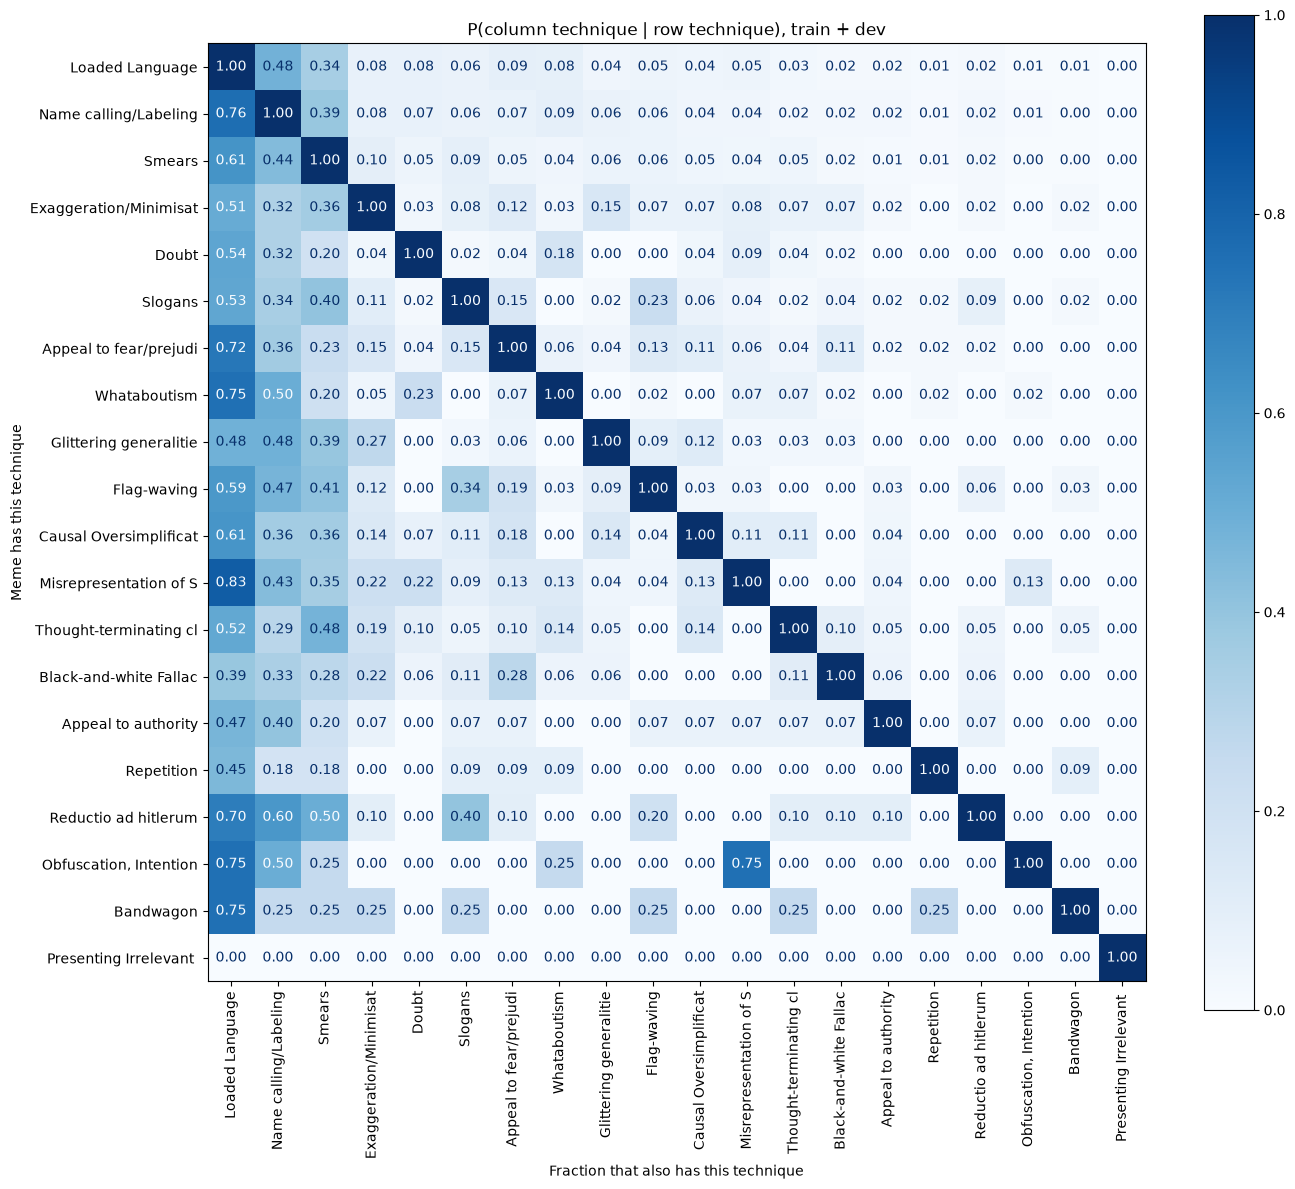

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay

TECHNIQUES = names
n_tech = len(TECHNIQUES)

together = np.zeros((n_tech, n_tech))
for labels in trainval_df['labels']:
    for a in labels:
        for b in labels:
            i = TECHNIQUES.index(a)
            j = TECHNIQUES.index(b)
            together[i, j] += 1

cond_prob = np.zeros((n_tech, n_tech))
for i in range(n_tech):
    for j in range(n_tech):
        cond_prob[i, j] = together[i, j] / together[i, i]

print('Most common partner for each technique:')
for i in range(n_tech):
    best_j = -1
    best_p = 0
    for j in range(n_tech):
        if j != i and cond_prob[i, j] > best_p:
            best_p = cond_prob[i, j]
            best_j = j
    n_memes = int(together[i, i])
    if best_j == -1:
        print(f'  {TECHNIQUES[i]} ({n_memes} memes): never appears with another technique')
    else:
        print(f'  {TECHNIQUES[i]} ({n_memes} memes): {TECHNIQUES[best_j]} {best_p:.0%}')

short_names = []
for t in TECHNIQUES:
    short_names.append(t[:22])

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(cond_prob, display_labels=short_names)
disp.plot(ax=ax, xticks_rotation=90, cmap='Blues', colorbar=True, values_format='.2f')
ax.set_title('P(column technique | row technique), train + dev')
ax.set_ylabel('Meme has this technique')
ax.set_xlabel('Fraction that also has this technique')
plt.tight_layout()
plt.show()

Looking at the results, `Loaded Language` is clearly the most common partner for 18 out of 19 other techniques. The one technique left over is Red Herring and it has no other technique.
This could partly be explained by the fact that `Loaded Language` is in 389/751 memes, which is over 50%, which means other techniques often appear in the same meme as it by chance, since it is in so many memes.
But some rows that have a REALLY high percentage of appearing in the same meme as `Loaded Language` are more telling, such as `Misrepresentation of Someone's Position (Straw Man)` (83%), `Name calling/Labeling` (76%), `Whataboutism` (75%) and `Appeal to fear/prejudice` (72%).
Evidently the results aren't symmetric: 76% of memes that have `Name calling/Labeling` in them also have `Loaded Language`, but only 48% of memes that have `Loaded Language` have `Name calling/Labeling`.
The fact that according to the results 75% of memes that have `Obfuscation, Intentional vagueness, Confusion` and 75% that have `Bandwagon` also have `Loaded Language` looks like a strong correllation on paper, but those are only based on 4 memes. The value is way too little to be enough to make that conclusion, so they cannot be trusted to not just be a coincidence and therefore have to be ignored.

The model could potentially learn a shortcut of always predicting `Loaded Language` as soon as it sees another technique that often appears with `Loaded Language`, without even looking and finding the loaded words. We'll need to address this later and keep it in mind to look for this behavior in the error analysis section.
There also could be a situation, where a technique is predicted ONLY because it usually appears with another one by the label head, but the span head is unable to find the actual text span containing that technique, meaning the two heads could disagree. This will be discussed in C3.

### Meme lengths

The length of the memes matters, since it will decide the max sequence length we will tell the model.
If we set the max sequence length too short, we could be cutting off important context and losing techniques that are i nit, if we set it too long - we are wasting memory and time on useless padding, which we can't afford due to the model speed constraint.

Meme length stats (words per meme):
count    751.000000
mean      17.950732
std       11.512844
min        1.000000
25%       10.000000
50%       15.000000
75%       24.000000
max       72.000000
Name: text, dtype: float64


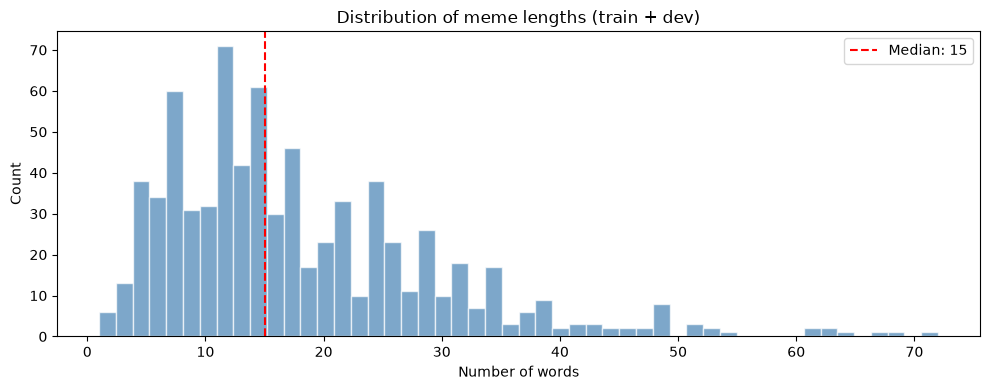

In [9]:
word_counts = trainval_df['text'].apply(lambda x: len(str(x).split()))

print('Meme length stats (words per meme):')
print(word_counts.describe())

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(word_counts, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
ax.axvline(word_counts.median(), color='red', linestyle='--', label=f'Median: {word_counts.median():.0f}')
ax.set_xlabel('Number of words')
ax.set_ylabel('Count')
ax.set_title('Distribution of meme lengths (train + dev)')
ax.legend()
plt.tight_layout()
plt.show()

The memes are mostly short. A median meme is 15 words long and 75% of all memes have <=24 words. As expected the distribution has a long tail - most memes are short, but there are some outliers (max length is 72 words).
This information is valuable, since now we know that even the longest meme is a lot shorter than what BERT-type encoders accept (512 tokens), so we can comfortably pick a max sequence length that fits every meme in full and would never cut off a technique.

- Short inputs are good for the school hardware constraint, since going through a 2-digit token number is not too compute-heavy, so the speed of the output in class should not be a problem.
- But, a good portion of the memes (25%) have <=10 words, which might be challenging for the model due to lack of text, especially knowing that the actual meme image that carries most of the context and message is not present. The model will likely struggle with the really short memes.

### Looking at technique spans

For Part B, the model has to find where each technique from the meme is actually in the text (which span of text contains it). We need to get an understanding of what those spans look like.
For each technique out of the 20 we will measure how long their spans are (in terms of words and also in terms of the percentage of the whole meme).
It is also important for us to check whether a span from one technique can overlap with a span from another technique and whether it happens often.

If spans from different techniques often contain same words (and overlap in those words), a singular tag per word wouldn't work, since we need a way to have a separate tag for each technique in those cases.

Total spans: 1680

Median span length per technique:
  Loaded Language (611 spans): 1 words, 9% of the meme
  Name calling/Labeling (338 spans): 2 words, 12% of the meme
  Smears (221 spans): 15 words, 96% of the meme
  Exaggeration/Minimisation (66 spans): 5 words, 29% of the meme
  Doubt (58 spans): 12 words, 60% of the meme
  Slogans (52 spans): 3 words, 19% of the meme
  Appeal to fear/prejudice (50 spans): 8 words, 39% of the meme
  Whataboutism (44 spans): 23 words, 95% of the meme
  Glittering generalities (Virtue) (34 spans): 10 words, 55% of the meme
  Flag-waving (38 spans): 4 words, 22% of the meme
  Causal Oversimplification (30 spans): 13 words, 64% of the meme
  Misrepresentation of Someone's Position (Straw Man) (23 spans): 16 words, 68% of the meme
  Thought-terminating cliché (22 spans): 4 words, 11% of the meme
  Black-and-white Fallacy/Dictatorship (18 spans): 9 words, 79% of the meme
  Appeal to authority (15 spans): 21 words, 99% of the meme
  Repetition (41 spans)

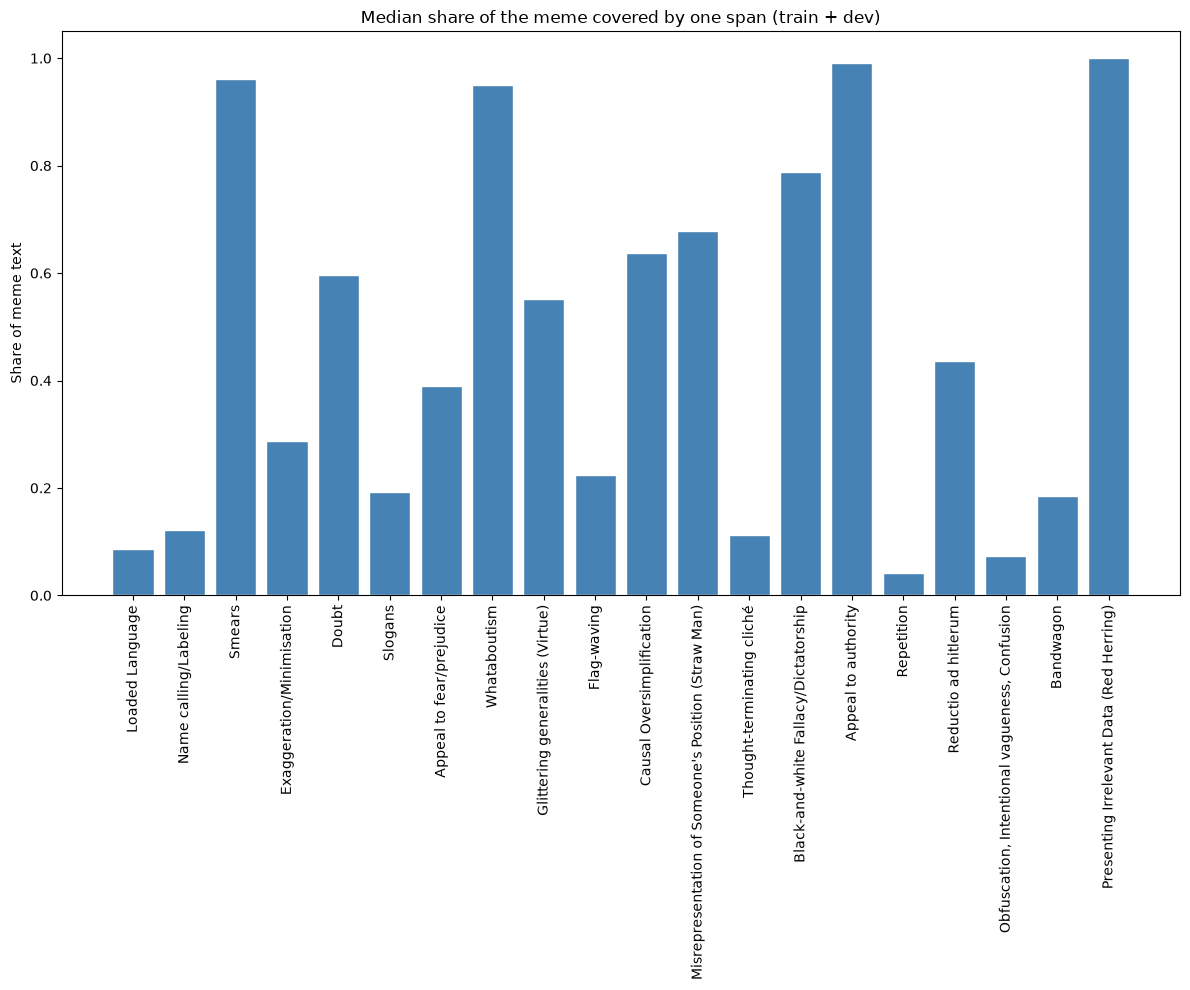

In [10]:
span_rows = []
for text, spans in zip(trainval_df['text'], trainval_df['spans']):
    for span in spans:
        span_text = text[span['start']:span['end']]
        n_words = len(span_text.split())
        meme_share = (span['end'] - span['start']) / len(text)
        span_rows.append({'technique': span['technique'], 'words': n_words, 'meme_share': meme_share})

span_df = pd.DataFrame(span_rows)
print(f'Total spans: {len(span_df)}\n')

median_shares = []
print('Median span length per technique:')
for technique in TECHNIQUES:
    rows = span_df[span_df['technique'] == technique]
    median_words = rows['words'].median()
    median_share = rows['meme_share'].median()
    median_shares.append(median_share)
    print(f'  {technique} ({len(rows)} spans): {median_words:.0f} words, {median_share:.0%} of the meme')

overlapping = 0
total = 0
for spans in trainval_df['spans']:
    for a in spans:
        total += 1
        for b in spans:
            different = b['technique'] != a['technique']
            touches = a['start'] < b['end'] and b['start'] < a['end']
            if different and touches:
                overlapping += 1
                break

overlap_percent = 100 * overlapping / total
print(f'\nSpans that overlap a span of a different technique: {overlapping} of {total} ({overlap_percent:.1f}%)')

fig, ax = plt.subplots(figsize=(12, 10))
ax.bar(TECHNIQUES, median_shares, color='steelblue', edgecolor='white')
ax.set_title('Median share of the meme covered by one span (train + dev)')
ax.set_ylabel('Share of meme text')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

So there are 1680 spans in total. Majority of them (76.1%) overlap with a span of a different technique, which means that the model really can't give each word just one singular technique.
Part B will need to be able to have a True/False for each of the 20 techniques for each word in the meme. A lot of this overlap comes from `Smears`, since the spans of that technique tend to cover mostly the entire meme (96%).
So whenever a meme that has `Smears` in it has another technique in it, they end up overlapping.

Looking at the data, there are 2 distinct groups of techniques:
- **Techniques with short spans** - `Loaded Language` (median 1 word), `Name calling` (2), `Repetition` (2) and `Slogans` (3). Here the span specifies exactly which words do the work for the technique, which is exactly what we want.
- **Techniques covering the whole meme** - `Smears` (96% of the meme), `Whataboutism` (95%), `Appeal to authority` (99%), `Black-and-white Fallacy` (79%). For these, specifying the specific text span doesn't add much useful information to the already given label.

This will influence Part B performance measuring decisions, since a model can easily get whole meme techniques correct by just taking the whole meme text as a span. The span scores will need to be evaluated per technique and not just as average.

### Checking if the dev set is big enough for being used as validation set

As we have already seen the data is given to us already separated into train and dev sets, where the dev set is meant for validation.
Let's decide if we canuse it for validation.
It needs to include examples of all techniques, since if a technique has no examples in the validation set, then it can't be scored on that technique.

In [11]:
dev_df = trainval_df[trainval_df['split'] == 'dev']

dev_counts = Counter()
for labels in dev_df['labels']:
    dev_counts.update(labels)

print(f'Technique counts in the dev set ({len(dev_df)} memes):')
zero_in_dev = 0
one_in_dev = 0
for technique in TECHNIQUES:
    count = dev_counts[technique]
    print(f'-{technique}: {count}')
    if count == 0:
        zero_in_dev += 1
    if count == 1:
        one_in_dev += 1

print(f'\nTechniques with no dev examples: {zero_in_dev} of {len(TECHNIQUES)}')
print(f'Techniques with exactly 1 dev example: {one_in_dev} of {len(TECHNIQUES)}')

Technique counts in the dev set (63 memes):
-Loaded Language: 31
-Name calling/Labeling: 29
-Smears: 18
-Exaggeration/Minimisation: 7
-Doubt: 8
-Slogans: 3
-Appeal to fear/prejudice: 4
-Whataboutism: 4
-Glittering generalities (Virtue): 1
-Flag-waving: 5
-Causal Oversimplification: 1
-Misrepresentation of Someone's Position (Straw Man): 3
-Thought-terminating cliché: 1
-Black-and-white Fallacy/Dictatorship: 0
-Appeal to authority: 2
-Repetition: 3
-Reductio ad hitlerum: 1
-Obfuscation, Intentional vagueness, Confusion: 0
-Bandwagon: 2
-Presenting Irrelevant Data (Red Herring): 0

Techniques with no dev examples: 3 of 20
Techniques with exactly 1 dev example: 4 of 20


The dev set is definitely way too small to serve as a set for held-out validation by itself. 3/20 techniques (`Black-and-white Fallacy/Dictatorship`, `Obfuscation, Intentional vagueness, Confusion` and `Presenting Irrelevant Data (Red Herring)`) have no examples in the dev set, so they can't be scored at all. Another 4 techniques have only 1 example, meaning they can't be reliably scored, since the performance measure could be 1 or 0 for that entire technique based on just 1 meme. Furthermore, 12/20 techniques have <=3 examples in the dev set, meaning more than half of all techniques has very little representation in the dev set.
<br>
We would like to score each technique equally and not discriminate across minority classes, so this validation set is way too unreliable. Instead, we will join train and dev sets and use 5-fold cross-validation instead of held-out validation. Each fold will have 150 memes, which is way more than the provided dev set and every meme will be used for validation once. The averaging of the 5 scores from the 5 folds will also help us see whether the result is stable or not.
That being said, techniques such as `Presenting Irrelevant Data (Red Herring)`, `Bandwagon` and `Obfuscation, Intentional vagueness, Confusion` will likely still be way too uncommon to be scored reliably in any of the folds, which will need to be reported as another limitation of this approach.

### Duplicate memes
Since our data isn't too extensive, later we will be joining train and dev sets together and splitting them into 5 folds to do cross-validation instead of just using the dev set for hold-out validation. If the same meme somehow appears twice, there is a possibility that one copy could end up in a train fold and the other in the val fold, so the model would be getting evaluated on a meme it's seen, which would make the validation score for that round of validation higher than it is supposed to be.
<br>
On the other hand if the same meme appears in both the train set and the test set, the model will be getting tested on a meme it has already seen, which would affect the test scores. This would be **leaky evaluation** and we have to avoid that.
We will compare every pair of memes across all three sets and print the pair in case their text is 90+% identical. We'll be removing punctuation and converting to lowercase prior to the check.
We will simply compare the text- the labels won't be shown and the test set is not going to be altered in any way. If a train or dev set meme has a duplicate in the test set, we will remove the copy from the dev/train sets.
However, the duplicates that are inside train and dev will be kept for now and dealt with when doing the cross-validation.

In [12]:
import difflib

def clean_text(text):
    cleaned = ''
    for ch in text.lower():
        if ch.isalnum() or ch == ' ':
            cleaned += ch
        else:
            cleaned += ' '
    words = cleaned.split()
    return ' '.join(words)

clean_texts = []
for text in df['text']:
    clean_texts.append(clean_text(text))

leaked_rows = []
print(f'Meme pairs with at least 90% similar text:')
for i in range(len(df)):
    for j in range(i + 1, len(df)):
        matcher = difflib.SequenceMatcher(None, clean_texts[i], clean_texts[j])
        if matcher.quick_ratio() < 0.9:
            continue
        similarity = matcher.ratio()
        if similarity < 0.9:
            continue
        split_i = df['split'][i]
        split_j = df['split'][j]
        print(f'\n{split_i} id {df["id"][i]}  vs  {split_j} id {df["id"][j]}  ({similarity:.0%} similar)')
        print(f'text: {clean_texts[i][:80]}')
        if split_i != 'test' and split_j == 'test':
            leaked_rows.append(i)
            print('!!!: one copy is in the test set: the train/dev copy will be removed')
        elif split_i == 'test' and split_j != 'test':
            leaked_rows.append(j)
            print('!!!: one copy is in the test set: the train/dev copy will be removed')
        elif split_i == 'test' and split_j == 'test':
            print('!!!: both copies are in the test set: nothing to remove')
        else:
            print(f'labels: {df["labels"][i]}  vs  {df["labels"][j]}')

trainval_df = df[df['split'] != 'test']
trainval_df = trainval_df.drop(index=leaked_rows)
print(f'\nRemoved {len(leaked_rows)} train/dev memes that also appear in the test set')
print(f'Train + dev memes left: {len(trainval_df)}')

Meme pairs with at least 90% similar text:

training id 93  vs  training id 110  (100% similar)
text: the real virus threatening america
labels: ['Loaded Language']  vs  ['Appeal to fear/prejudice', 'Flag-waving']

training id 474_batch_2  vs  test id 474_batch_2  (100% similar)
text: joe biden s lifetime accomplishments
!!!: one copy is in the test set: the train/dev copy will be removed

training id 549_batch_2  vs  dev id 30_batch_2  (100% similar)
text: still more coherent than joe biden
labels: []  vs  []

training id 588_batch_2  vs  training id 501_batch_2  (100% similar)
text: how to kill the coronovirus hey hillary i hear the coronavirus is going to testi
labels: ['Loaded Language', 'Smears']  vs  ['Smears']

Removed 1 train/dev memes that also appear in the test set
Train + dev memes left: 750


There are 4 duplicate pairs with 100% similarity.
One of them was a training meme that has the same text as a meme in the test set ("joe biden s lifetime accomplishments"). As a result, the train copy was removed, meaning there are 750 memes in train and dev sets left now. Test set remains unchanged.
<br>
Other 3 duplicate pairs were inside train and dev sets. Interestingly 2 of them had the same exact text, but different labels. For example the text "the real virus threatening america" has `Loaded Language` technique in one instance and `Appeal to fear/prejudice` and `Flag-waving` in the other.
Most straightforward explanation is that the memes had different images, which is impossible to see for the model we are developing. It is impossible for a text based model to get both copies correct, since the text is identical in both, so this reinforces the lack of visual information limitation mentioned before. It tells us that expecting a very high performance from this model is unreasonable.
The 3 duplicate pairs are kept for now, but we'll put them in the same fold when we are doing cross-validation later.

## Step 3. **Performance measure choosing + performance target setting**

Before building the models, we'll have to pick a performance measure to judge how well our models are performing. This is different to choosing a loss funciton - loss is what the model uses during training to pick optimal weights, while the performance measure is for us to decide which model is doing better.

**Part A**: **macro-F1 score**. We will be finding out a separate F1 score for each of the 20 techniques and then averaging them, so that all the 20 techniques matter and contribute to the score equally without discrimination. This decision is driven by huge data imbalances found during the EDA stage. Accuracy would make the model look way better than it actually is in case it resorts to predicting `Loaded Language` and `Name calling/Labeling` (and maybe other most common techniques) only. Macro-F1 will be the deciding factor for all learning curves, model comparisons and final result too.

**Part B**: **word-level macro-F1**. The model will give every single word a true/false (or yes/no) for each of the 20 techniques. We'll be scoring the true/false answers like in part A - F1 per each technique, averaged across 20. This way short span techniques (`Loaded Language`) will matter as much as whole text (whole meme) techniques like `Smears`.

In [13]:
from sklearn.metrics import f1_score

y_true = []
for labels in trainval_df['labels']:
    row = []
    for technique in TECHNIQUES:
        if technique in labels:
            row.append(1)
        else:
            row.append(0)
    y_true.append(row)
y_true = np.array(y_true)

technique_counts = y_true.sum(axis=0)
most_common = technique_counts.argmax()
print(f'Most common technique: {TECHNIQUES[most_common]}\n')

baselines = {}

y_pred = np.zeros(y_true.shape)
y_pred[:, most_common] = 1
baselines['Always predicting most common technique'] = y_pred

y_pred = np.ones(y_true.shape)
baselines['Predict all 20 techniques for EVERY meme'] = y_pred

np.random.seed(SEED)
y_pred = np.random.randint(0, 2, size=y_true.shape)
baselines['Random true/false for each technique'] = y_pred

for name in baselines:
    y_pred = baselines[name]
    macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    print(f'{name}: macro-F1 {macro:.3f}')

Most common technique: Loaded Language

Always predicting most common technique: macro-F1 0.034
Predict all 20 techniques for EVERY meme: macro-F1 0.139
Random true/false for each technique: macro-F1 0.116


If we always predict `Loaded Language`, which is the most common technique, we get a very bad F1 score of `0.034`, which showcases how F1 prevents discrimination of minority classes. The score is so low, because the other 19 techniques get F1 of 0, so after averaging across all 20 techniques, the final F1 is really low.

Out of the three baselines, guessing all 20 techniques for each meme scores the highest giving an F1 of `0.139`, which is interestingly higher than guessing randomly (F1 of `0.116`).

In conclusion, the floor that the model HAS to beat is `0.139`. Also, evidently a model that predicts more techniques rather than less may score higher than it should without learning that much, so when we are weighting the loss towards some of the rarer techniques, we should be checking the per-technique scores to make sure that the score gain is trustworthy.

### Setting target performance values

We can set the target after making judgements based on a published result + the baseline values above.

The mentioned published result comes from the paper that came with the dataset that we are using (Dimitrov et al., 2021). There was a competition where teams all worked on this same task.
The winner's best macro F1 score their model has reached was a macro-F1 of `0.29` (on test set), however they had more time for development, could use bigger models and combine multiple.
As we know, our baseline benchmark is `0.139`. We also know that the problem is really difficult: only 750 memes with a sharp speed and hardware constraint. Many of the techniques have very little representation in the actual dataset, one of the techniques has only 1 meme that has it.

A reasonable target would be a macro-F1 of `0.24` for Part A on the test set. It comfortably beats the chosen floor and is under the competition's result, who had less constraints. I believe that macro-F1 of `0.24` is a realistic expectation for this model under the specified constraints.
The target for Part B will be set later.

In [14]:
TARGET_METRIC = 'macro-F1'
TARGET_VALUE = 0.24

## Step 4. Splitting the data.

As stated in multiple EDA markdown cells, we will do 5-fold cross-validation over the joined dev + train set, instead of just using the provided dev set for held-out validation, which is too small. Each of the folds will take turns being the validation set after the model trains on the other 4 folds. This way every meme will be used for both training and evaluation.

We'll use `GroupKFold` instead of `StratifiedKFold`, since that one wants a singular label per example, which is impossible for this proboem. We also need to keep the 3 duplicate pairs that we found in a single fold to make sure the model is never evaluated on a meme it has seen previously.

In [15]:
from sklearn.model_selection import GroupKFold

N_FOLDS = 5

groups = []
for text in trainval_df['text']:
    groups.append(clean_text(text))

gkf = GroupKFold(n_splits=N_FOLDS)
fold_of_meme = np.zeros(len(trainval_df), dtype=int)
for fold, (train_idx, val_idx) in enumerate(gkf.split(trainval_df, groups=groups)):
    fold_of_meme[val_idx] = fold
trainval_df['fold'] = fold_of_meme

print('Memes per fold:')
for fold in range(N_FOLDS):
    n_memes = (trainval_df['fold'] == fold).sum()
    print(f'  Fold {fold}: {n_memes} memes')

print('\nDuplicate memes and their folds:')
for group in sorted(set(groups)):
    if groups.count(group) > 1:
        folds = []
        for i in range(len(groups)):
            if groups[i] == group:
                folds.append(int(fold_of_meme[i]))
        print(f'  "{group[:40]}": folds {folds}')

print('\nTechnique examples per fold:')
for technique in TECHNIQUES:
    counts = []
    for fold in range(N_FOLDS):
        count = 0
        for labels in trainval_df[trainval_df['fold'] == fold]['labels']:
            if technique in labels:
                count += 1
        counts.append(count)
    print(f'  {technique[:40]:<40} {counts}')

Memes per fold:
  Fold 0: 150 memes
  Fold 1: 150 memes
  Fold 2: 150 memes
  Fold 3: 150 memes
  Fold 4: 150 memes

Duplicate memes and their folds:
  "how to kill the coronovirus hey hillary ": folds [2, 2]
  "still more coherent than joe biden": folds [1, 1]
  "the real virus threatening america": folds [0, 0]

Technique examples per fold:
  Loaded Language                          [77, 79, 80, 76, 77]
  Name calling/Labeling                    [44, 49, 45, 50, 59]
  Smears                                   [52, 46, 33, 47, 40]
  Exaggeration/Minimisation                [12, 9, 13, 15, 10]
  Doubt                                    [10, 14, 9, 8, 15]
  Slogans                                  [7, 8, 13, 9, 10]
  Appeal to fear/prejudice                 [13, 2, 11, 13, 8]
  Whataboutism                             [12, 11, 5, 10, 6]
  Glittering generalities (Virtue)         [6, 10, 4, 5, 8]
  Flag-waving                              [9, 4, 5, 8, 6]
  Causal Oversimplification       

As expected, each of the 5 folds has 150 memes. Each pair of duplicates also ended up in the same fold, meaning the danger of valiating on the same meme used in training is mitigated.

Common techniques are spread evenly across the folds, for example `Loaded Language` is [77, 79, 80, 76, 77].
Unfortunately, the rarer techniques, such as `Obfuscation`, `Bandwagon` and `Reductio ad hitlerum` are all missing from at least one of the folds. And of course since `Red Herring` is only in one meme, it is present in only one fold.

This means that when a model is evaluated, but some technique is not represented in the val fold, the F1 of that technique will be 0, which will lower the whole fold's macro-F1 down.
This is fine, since seeing how big the spread across the 5 F1 values is will tell us how certain or uncertain the final results are, so we will be reporting the spread of the values and not just the average.

## Step 5. Encoder + tokenization

We will use DistilBERT, which is the pretrained transformer used in labs. It fits our constraints:
- 66 mil parameters and about ~60% faster than BERT, so it should comfortably fit on one T4 GPU (**hardware constraint**) and output predictions quickly.
- The weights will be downloaded once and run locally on the machine, which addresses the **privacy constraint**.
- It was trained on neutral Wikipedia articles and books, not specifically on persuasion or propaganda text (**no shortcut checkpoints**).

There is a limitation: everything will get lowercased, so it won't be able to see words written in capital letters. Often memes have capitalized words to add emphasis or extra emotional sentiment.

DistilBERT's tokenizer will split the rare words into smaller pieces. A meme will likely have more tokens than words. As we know, the longest meme had 72 words, so we will check the token count stats after tokenization to guide the max length decision.

In [16]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

token_counts = []
for text in trainval_df['text']:
    tokens = tokenizer(text)['input_ids']
    token_counts.append(len(tokens))
token_counts = pd.Series(token_counts)

print(token_counts.describe())

count    750.000000
mean      25.604000
std       15.271962
min        3.000000
25%       14.000000
50%       22.000000
75%       34.000000
max      101.000000
dtype: float64


The memes show an average of `25.604` tokens and a median of `22 tokens`. The median in terms of words per meme was `15`, so as we can see the tokenizer is doing its job and splitting some words into parts, since there are more tokens than words. The longest meme in terms of tokens is 101 (was 72 in terms of words).
We'll go with a max length of 128 (same as week 8 lab). This will comfortably cover every meme present in train + dev sets, so no meme will get cut off. It also leaves a little bit of extra room in case there are memes in test set that are longer than 101 tokens, which we can't know without peeking into the test set. Most of the memes are significantly shorter than 128 tokens, but since we only have 750 memes in train + dev sets, the extra compute due to padding should not matter that much.

## Step 6. Dataset

We'll now turn memes into a PyTorch dataset by creating a class. It will tokenize each meme and pad them to 128 tokens.
The difference to the lab 8 class is that in that class one example only had one class number, but here instead we have 20 separate true/false labels for each technique, which are stored as decimals (0.0 for false and 1.0 for true).

We'll make one dataset for all 750 memes we have in dev + train sets. Each of the 5 folds we created will pick the train and val memes from the dataset.

In [17]:
from torch.utils.data import Dataset, DataLoader, Subset

class MemeDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.labels = labels
        self.encodings = tokenizer(
            texts,
            padding='max_length',
            truncation=True,
            max_length=max_length,
            return_tensors='pt',
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': torch.tensor(self.labels[idx], dtype=torch.float),
        }

full_ds = MemeDataset(trainval_df['text'].tolist(), y_true, tokenizer, max_length=128)
print(f'Dataset size: {len(full_ds)}')

example = full_ds[0]
print(f'labels: {example["labels"]}')

Dataset size: 750
labels: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 0.])


So, now every meme has 128 token IDs with an attention mask based on them, as well as 20 T/F labels (0.0 or 1.1) for each technique.

## Step 7. Model

We'll load the plain DistilBERT encodes and then add our own head on top of it.
DistilBERT takes the meme as an input and outputs a vector which summarizes that meme.
Our head wil be a dropout layer and a linear layer with 20 outputs, which are 1 score/1 technique.

First, we freeze DistilBERT to train just the head first.

In [18]:
import torch.nn as nn
from transformers import AutoModel

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

class MemeClassifier(nn.Module):
    def __init__(self, num_labels=20):
        super().__init__()
        self.encoder = AutoModel.from_pretrained('distilbert-base-uncased', token=False)
        self.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(768, num_labels),
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_vector = outputs.last_hidden_state[:, 0, :]
        return self.head(cls_vector)

model = MemeClassifier().to(device)
for param in model.encoder.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'Trainable: {trainable:,} / {total:,} ({trainable/total*100:.2f}%)')

check_loader = DataLoader(full_ds, batch_size=32, shuffle=False)
batch = next(iter(check_loader))
input_ids = batch['input_ids'].to(device)
attention_mask = batch['attention_mask'].to(device)
logits = model(input_ids, attention_mask)
print(f'Output shape: {logits.shape}')

Using device: cuda


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trainable: 15,380 / 66,378,260 (0.02%)
Output shape: torch.Size([32, 20])


The head has 15380 weights. The model outputs 20 scores for each meme in the batch (one/technique).
There are total 66.4 million weights, most of which come from DistilBERT, which is currently frozen, so only the head weights will be trained.

## Step 8. Training and evaluation functions.

We'll mostly reuse Lab 8 code here for training functions.
The necessary changes:
- **Loss**: we'll use binary cross-entropy for each of the techniques.
- **Measure**: a sigmoid function will turn each technique's score into a probability between 0 and 1. A technique will be predicted only if its probability is > 0.5. We'll track and plot macro-F1 scores instead of accuracy.
- **Best epoch**: we'll keep the weights from the best epoch that had the highest validation macro-F1 score.


In [19]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    total = 0
    all_labels = []
    all_preds = []
    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        y = batch['labels'].to(device)
        logits = model(input_ids, attention_mask)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        probs = torch.sigmoid(logits)
        predicted = (probs > 0.5).int()
        all_labels.append(y.cpu().numpy())
        all_preds.append(predicted.cpu().numpy())
        total += y.size(0)
    all_labels = np.vstack(all_labels)
    all_preds = np.vstack(all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / total, f1


def evaluate_model(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total = 0
    all_labels = []
    all_preds = []
    with torch.inference_mode():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            y = batch['labels'].to(device)
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, y)

            total_loss += loss.item() * y.size(0)
            probs = torch.sigmoid(logits)
            predicted = (probs > 0.5).int()
            all_labels.append(y.cpu().numpy())
            all_preds.append(predicted.cpu().numpy())
            total += y.size(0)
    all_labels = np.vstack(all_labels)
    all_preds = np.vstack(all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / total, f1


def run_experiment(model, optimizer, criterion, train_loader, val_loader,
                   epochs=10, name='Model', save_path='best_model.pth'):
    history = {'train_loss': [], 'train_f1': [], 'val_loss': [], 'val_f1': []}
    best_val = -1.0
    best_epoch = 0
    for epoch in range(epochs):
        tl, tf = train_one_epoch(model, train_loader, optimizer, criterion)
        vl, vf = evaluate_model(model, val_loader, criterion)
        history['train_loss'].append(tl)
        history['train_f1'].append(tf)
        history['val_loss'].append(vl)
        history['val_f1'].append(vf)
        print(f'  [{name}] Epoch {epoch+1}/{epochs} — '
              f'Train: {tl:.4f} / {tf:.4f} | Val: {vl:.4f} / {vf:.4f}')
        if vf > best_val:
            best_val = vf
            best_epoch = epoch + 1
            torch.save(model.state_dict(), save_path)
    model.load_state_dict(torch.load(save_path))
    print(f'  [{name}] Best epoch: {best_epoch} (val macro-F1 {best_val:.4f})')
    return history


def plot_experiments(results, show_train=True, show_val=True):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for name, hist in results.items():
        epochs = range(1, len(hist['train_loss']) + 1)
        if show_train:
            axes[0].plot(epochs, hist['train_loss'], label=f'{name} (Train)', marker='o', markersize=3)
            axes[1].plot(epochs, hist['train_f1'], label=f'{name} (Train)', marker='o', markersize=3)
        if show_val:
            axes[0].plot(epochs, hist['val_loss'], label=f'{name} (Val)', linestyle='--', marker='x', markersize=3)
            axes[1].plot(epochs, hist['val_f1'], label=f'{name} (Val)', linestyle='--', marker='x', markersize=3)
    axes[1].axhline(TARGET_VALUE, color='red', linestyle=':', label='Target')
    for ax, ylabel in zip(axes, ['Loss', 'Macro-F1']):
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        ax.legend(fontsize=8)
        ax.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

## Step 9. Baseline mode with frozen DistilBERT

The first model we develop will keep all weights from DistilBERT fromzen and only train our custom head using plain loss.
We'll use Adam with learning rate of 1e-3. We'll do 10 epochs.
We'll train 5 separate models, one per fold. Every time, one fold is held out to be the validation set and the new model is trained on the other four folds. As we said, each fold gets used as a validation set once.


--- Fold 0 ---


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [Fold 0] Epoch 1/10 — Train: 0.4038 / 0.0674 | Val: 0.2619 / 0.0346
  [Fold 0] Epoch 2/10 — Train: 0.2307 / 0.0354 | Val: 0.2397 / 0.0335
  [Fold 0] Epoch 3/10 — Train: 0.2193 / 0.0345 | Val: 0.2347 / 0.0354
  [Fold 0] Epoch 4/10 — Train: 0.2130 / 0.0391 | Val: 0.2311 / 0.0325
  [Fold 0] Epoch 5/10 — Train: 0.2090 / 0.0394 | Val: 0.2280 / 0.0345
  [Fold 0] Epoch 6/10 — Train: 0.2068 / 0.0449 | Val: 0.2250 / 0.0375
  [Fold 0] Epoch 7/10 — Train: 0.2030 / 0.0542 | Val: 0.2226 / 0.0446
  [Fold 0] Epoch 8/10 — Train: 0.1998 / 0.0557 | Val: 0.2207 / 0.0424
  [Fold 0] Epoch 9/10 — Train: 0.1967 / 0.0552 | Val: 0.2182 / 0.0474
  [Fold 0] Epoch 10/10 — Train: 0.1948 / 0.0643 | Val: 0.2168 / 0.0476
  [Fold 0] Best epoch: 10 (val macro-F1 0.0476)

--- Fold 1 ---


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [Fold 3] Epoch 1/10 — Train: 0.3989 / 0.0808 | Val: 0.2557 / 0.0329
  [Fold 3] Epoch 2/10 — Train: 0.2334 / 0.0266 | Val: 0.2344 / 0.0366
  [Fold 3] Epoch 3/10 — Train: 0.2199 / 0.0355 | Val: 0.2295 / 0.0351
  [Fold 3] Epoch 4/10 — Train: 0.2161 / 0.0364 | Val: 0.2242 / 0.0388
  [Fold 3] Epoch 5/10 — Train: 0.2103 / 0.0377 | Val: 0.2208 / 0.0420
  [Fold 3] Epoch 6/10 — Train: 0.2075 / 0.0471 | Val: 0.2178 / 0.0436
  [Fold 3] Epoch 7/10 — Train: 0.2046 / 0.0494 | Val: 0.2150 / 0.0486
  [Fold 3] Epoch 8/10 — Train: 0.2016 / 0.0479 | Val: 0.2132 / 0.0507
  [Fold 3] Epoch 9/10 — Train: 0.1988 / 0.0599 | Val: 0.2105 / 0.0579
  [Fold 3] Epoch 10/10 — Train: 0.1975 / 0.0568 | Val: 0.2091 / 0.0545
  [Fold 3] Best epoch: 9 (val macro-F1 0.0579)

--- Fold 4 ---


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [Fold 4] Epoch 1/10 — Train: 0.4011 / 0.0780 | Val: 0.2445 / 0.0348
  [Fold 4] Epoch 2/10 — Train: 0.2362 / 0.0308 | Val: 0.2193 / 0.0379
  [Fold 4] Epoch 3/10 — Train: 0.2241 / 0.0358 | Val: 0.2152 / 0.0374
  [Fold 4] Epoch 4/10 — Train: 0.2178 / 0.0380 | Val: 0.2118 / 0.0379
  [Fold 4] Epoch 5/10 — Train: 0.2145 / 0.0453 | Val: 0.2082 / 0.0433
  [Fold 4] Epoch 6/10 — Train: 0.2096 / 0.0468 | Val: 0.2061 / 0.0443
  [Fold 4] Epoch 7/10 — Train: 0.2063 / 0.0468 | Val: 0.2041 / 0.0467
  [Fold 4] Epoch 8/10 — Train: 0.2048 / 0.0565 | Val: 0.2021 / 0.0473
  [Fold 4] Epoch 9/10 — Train: 0.2002 / 0.0630 | Val: 0.2015 / 0.0481
  [Fold 4] Epoch 10/10 — Train: 0.1991 / 0.0612 | Val: 0.1997 / 0.0470
  [Fold 4] Best epoch: 9 (val macro-F1 0.0481)


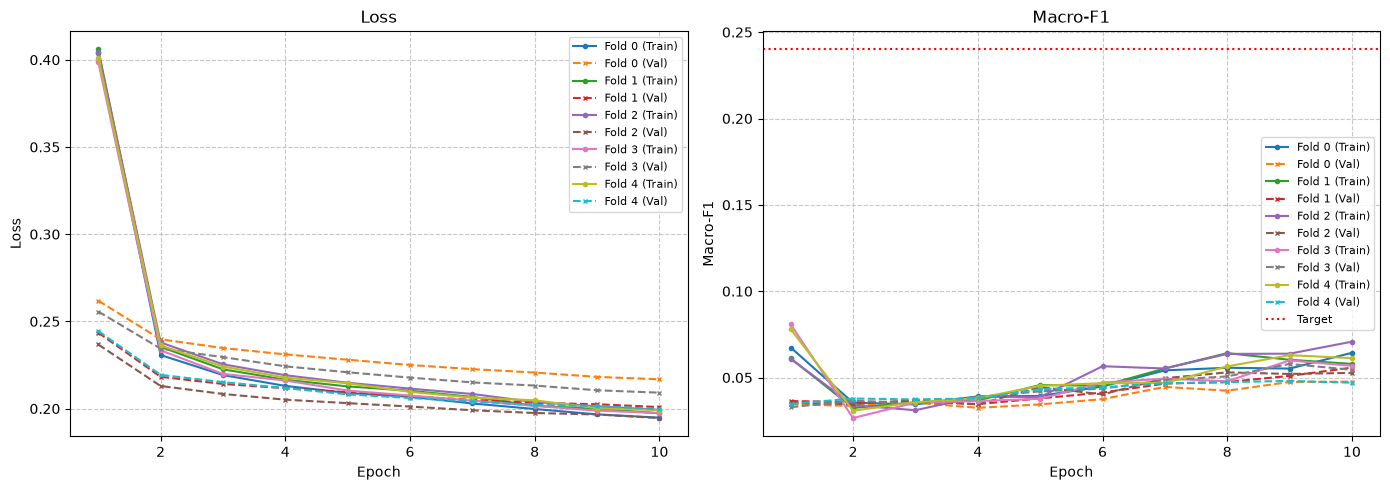

Fold 0: best val macro-F1 0.0476
Fold 1: best val macro-F1 0.0558
Fold 2: best val macro-F1 0.0530
Fold 3: best val macro-F1 0.0579
Fold 4: best val macro-F1 0.0481
Mean best val macro-F1: 0.0525 ± 0.0041


In [20]:
import torch.optim as optim

criterion = nn.BCEWithLogitsLoss()
frozen_results = {}

fold_list = trainval_df['fold'].tolist()
for fold in range(5):
    print(f'\n--- Fold {fold} ---')
    train_indices = []
    val_indices = []
    for i in range(len(fold_list)):
        if fold_list[i] == fold:
            val_indices.append(i)
        else:
            train_indices.append(i)
    train_loader = DataLoader(Subset(full_ds, train_indices), batch_size=32, shuffle=True)
    val_loader = DataLoader(Subset(full_ds, val_indices), batch_size=64, shuffle=False)

    torch.manual_seed(SEED)
    model = MemeClassifier().to(device)
    for param in model.encoder.parameters():
        param.requires_grad = False
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

    frozen_results[f'Fold {fold}'] = run_experiment(
        model, optimizer, criterion, train_loader, val_loader,
        epochs=10, name=f'Fold {fold}'
    )

plot_experiments(frozen_results)

best_scores = []
for name in frozen_results:
    best = max(frozen_results[name]['val_f1'])
    best_scores.append(best)
    print(f'{name}: best val macro-F1 {best:.4f}')
print(f'Mean best val macro-F1: {np.mean(best_scores):.4f} ± {np.std(best_scores):.4f}')

Before talking about results, let's see which techniques the model seems to be getting right (we look at fold 5).
We'll turn it into a function, since we'll be reusing it for looking at the other models too.

In [21]:
from sklearn.metrics import classification_report

def technique_report(model, loader):
    model.eval()
    all_preds, all_labels_list = [], []
    with torch.inference_mode():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            y = batch['labels']
            logits = model(input_ids, attention_mask)
            predicted = (torch.sigmoid(logits) > 0.5).int()
            all_preds.extend(predicted.cpu().numpy())
            all_labels_list.extend(y.numpy())
    all_preds = np.array(all_preds)
    all_labels_arr = np.array(all_labels_list)
    print(classification_report(all_labels_arr, all_preds, target_names=TECHNIQUES, zero_division=0))
    yes_counts = all_preds.sum(axis=0)
    for i in range(len(TECHNIQUES)):
        print(f'{TECHNIQUES[i][:40]:<40} predicted yes {yes_counts[i]} times')

technique_report(model, val_loader)

                                                     precision    recall  f1-score   support

                                    Loaded Language       0.78      0.75      0.77        77
                              Name calling/Labeling       1.00      0.02      0.03        59
                                             Smears       0.40      0.10      0.16        40
                          Exaggeration/Minimisation       0.00      0.00      0.00        10
                                              Doubt       0.00      0.00      0.00        15
                                            Slogans       0.00      0.00      0.00        10
                           Appeal to fear/prejudice       0.00      0.00      0.00         8
                                       Whataboutism       0.00      0.00      0.00         6
                   Glittering generalities (Virtue)       0.00      0.00      0.00         8
                                        Flag-waving       0.00      0

The frozen baseline model only reaches an average best validation macro-F1 of `0.0525` (the spread is +- `0.004`), which is very low. It does beat always predicting `Loaded Language` (score of `0.034`), but is significantly lower than the `0.139`, which we set as the floor and of course is not even close to the `0.24` target.

All 5 folds results were close.
The model looks to be underfitting, sicne the training and validation loss are decreasing together - training macro-F1 is as low as the validation macro-F1.
Also we are using unweighted loss, so simply predicting "no" for each rare technique will theoretically be the better choice for the model, meaning it essentially would ignore those.

Per-technique report for the final fold backs up that claim. The model only ever said "True" for 3 out of 20 techniques: `Name Calling` - 78 memes, `Name calling/Labeling` - once and `Smears` - 5 times. Other techniques were never predicted, meaning they get a score of 0.

So, next we will weight the loss towards the rarer techniques to avoid that issue, but keep everything else unchanged.
The best epochs for each fold were the later ones (8,9 and 10), so we should use more epochs than 10 from now on.

## Step 10. Weighted loss

The model we just developed completely ignores all the rarer techniques (17/20), because saying "False" for them is always the better choice for the model. Makes sense, since as observed in EDA, the most common technique being `Loaded Language` has 389x more representation in the dataset than the rarest technique (`Red Herring`).

To compensate for this and make the model not ignore the rare techniques, we need to weight the loss, such that missing a rare technique matters more than missing a common technique, so that the model is punished more for that. We'll use inverse-frequency class weights (total/class count).

This example shows how it works:
`Loaded Language` will get a weight of about 2 and `Red Herring` on the other hand will get a weight of about 600, so missing a `Red Herring` meme will be around 300 times more punishing to the model than missing a `Loaded Language` meme, which is the majority class.

We can't use weights with cross-entropy like the labs, since it only works for multi-classification, but we have multi-label classification, so we need 20 true/false answers for each word. We'll continue using binary cross-entropy (BCE), where a sigmoid activation function will turn the score of every technique into a value from 0.0 to 1.0. Value above 0.5 will be "true" and value below and including that will be "false".
We'll employ weights to increase the loss on the "True" examples for each technique.


--- Fold 0 ---
Class weights (inverse frequency, fold 0):
  Loaded Language                          1.92
  Name calling/Labeling                    2.96
  Smears                                   3.61
  Exaggeration/Minimisation                12.77
  Doubt                                    13.04
  Slogans                                  15.00
  Appeal to fear/prejudice                 17.65
  Whataboutism                             18.75
  Glittering generalities (Virtue)         22.22
  Flag-waving                              26.09
  Causal Oversimplification                25.00
  Misrepresentation of Someone's Position  35.29
  Thought-terminating cliché               46.15
  Black-and-white Fallacy/Dictatorship     40.00
  Appeal to authority                      50.00
  Repetition                               66.67
  Reductio ad hitlerum                     85.71
  Obfuscation, Intentional vagueness, Conf 200.00
  Bandwagon                                200.00
  Presentin

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [Fold 0] Epoch 1/10 — Train: 1.4390 / 0.1267 | Val: 1.4359 / 0.1515
  [Fold 0] Epoch 2/10 — Train: 1.3359 / 0.1523 | Val: 1.3344 / 0.1755
  [Fold 0] Epoch 3/10 — Train: 1.2737 / 0.1651 | Val: 1.3155 / 0.1938
  [Fold 0] Epoch 4/10 — Train: 1.2124 / 0.1931 | Val: 1.2962 / 0.2035
  [Fold 0] Epoch 5/10 — Train: 1.1613 / 0.2139 | Val: 1.2791 / 0.2447
  [Fold 0] Epoch 6/10 — Train: 1.1469 / 0.2189 | Val: 1.2613 / 0.2250
  [Fold 0] Epoch 7/10 — Train: 1.1151 / 0.2223 | Val: 1.2507 / 0.2459
  [Fold 0] Epoch 8/10 — Train: 1.0756 / 0.2437 | Val: 1.2379 / 0.2359
  [Fold 0] Epoch 9/10 — Train: 1.0396 / 0.2653 | Val: 1.2343 / 0.2222
  [Fold 0] Epoch 10/10 — Train: 1.0243 / 0.2865 | Val: 1.2337 / 0.2277
  [Fold 0] Best epoch: 7 (val macro-F1 0.2459)

--- Fold 1 ---


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [Fold 3] Epoch 1/10 — Train: 1.3912 / 0.1310 | Val: 1.3952 / 0.1547
  [Fold 3] Epoch 2/10 — Train: 1.3375 / 0.1550 | Val: 1.3934 / 0.1917
  [Fold 3] Epoch 3/10 — Train: 1.2395 / 0.1725 | Val: 1.3668 / 0.1882
  [Fold 3] Epoch 4/10 — Train: 1.2089 / 0.1921 | Val: 1.3279 / 0.2079
  [Fold 3] Epoch 5/10 — Train: 1.1642 / 0.2234 | Val: 1.3272 / 0.2156
  [Fold 3] Epoch 6/10 — Train: 1.1120 / 0.2452 | Val: 1.3136 / 0.2096
  [Fold 3] Epoch 7/10 — Train: 1.0992 / 0.2331 | Val: 1.2959 / 0.2127
  [Fold 3] Epoch 8/10 — Train: 1.0720 / 0.2732 | Val: 1.3086 / 0.2232
  [Fold 3] Epoch 9/10 — Train: 1.0447 / 0.2715 | Val: 1.3190 / 0.2147
  [Fold 3] Epoch 10/10 — Train: 1.0099 / 0.2780 | Val: 1.3225 / 0.2192
  [Fold 3] Best epoch: 8 (val macro-F1 0.2232)

--- Fold 4 ---


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [Fold 4] Epoch 1/10 — Train: 1.3919 / 0.1360 | Val: 1.1189 / 0.1655
  [Fold 4] Epoch 2/10 — Train: 1.3349 / 0.1620 | Val: 1.0986 / 0.1945
  [Fold 4] Epoch 3/10 — Train: 1.2463 / 0.1762 | Val: 1.0959 / 0.1757
  [Fold 4] Epoch 4/10 — Train: 1.2034 / 0.1980 | Val: 1.0915 / 0.1772
  [Fold 4] Epoch 5/10 — Train: 1.1769 / 0.2037 | Val: 1.0763 / 0.1912
  [Fold 4] Epoch 6/10 — Train: 1.1191 / 0.2288 | Val: 1.0711 / 0.1916
  [Fold 4] Epoch 7/10 — Train: 1.0868 / 0.2392 | Val: 1.0642 / 0.1897
  [Fold 4] Epoch 8/10 — Train: 1.0689 / 0.2745 | Val: 1.0702 / 0.1901
  [Fold 4] Epoch 9/10 — Train: 1.0345 / 0.2537 | Val: 1.0548 / 0.2030
  [Fold 4] Epoch 10/10 — Train: 1.0130 / 0.2734 | Val: 1.0299 / 0.2002
  [Fold 4] Best epoch: 9 (val macro-F1 0.2030)


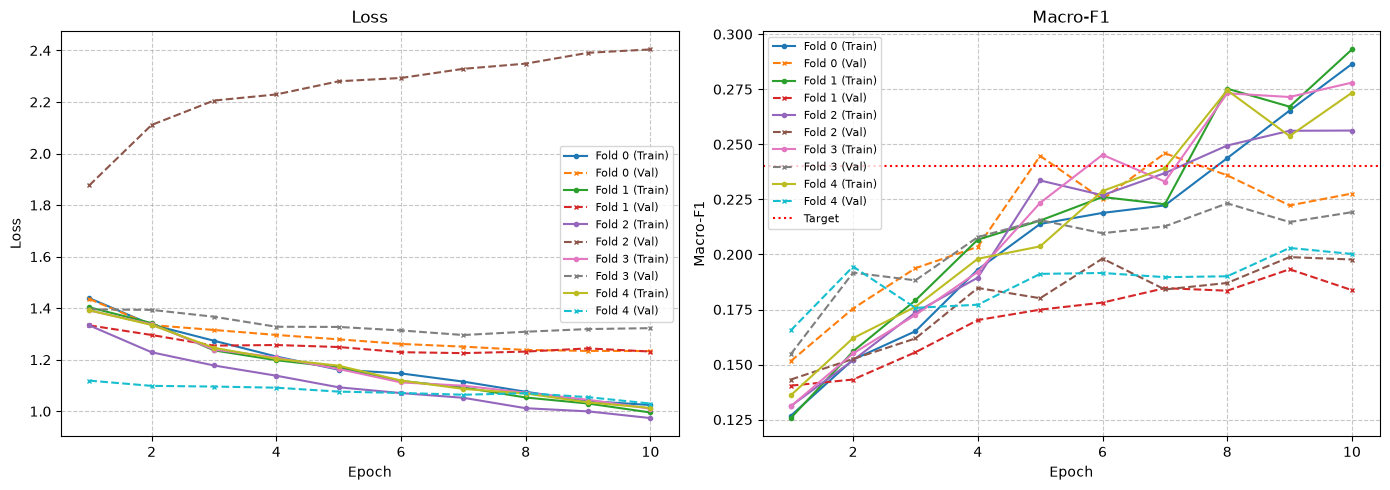

Fold 0: best val macro-F1 0.2459
Fold 1: best val macro-F1 0.1933
Fold 2: best val macro-F1 0.1988
Fold 3: best val macro-F1 0.2232
Fold 4: best val macro-F1 0.2030
Unweighted mean best val macro-F1: 0.0525 ± 0.0041
Weighted mean best val macro-F1:   0.2128 ± 0.0194


In [22]:
weighted_results = {}
for fold in range(5):
    print(f'\n--- Fold {fold} ---')
    train_indices = []
    val_indices = []
    for i in range(len(fold_list)):
        if fold_list[i] == fold:
            val_indices.append(i)
        else:
            train_indices.append(i)
    train_loader = DataLoader(Subset(full_ds, train_indices), batch_size=32, shuffle=True)
    val_loader = DataLoader(Subset(full_ds, val_indices), batch_size=64, shuffle=False)

    class_counts = y_true[train_indices].sum(axis=0)
    total = len(train_indices)
    pos_weight = torch.tensor([total / max(class_counts[i], 1) for i in range(len(TECHNIQUES))], dtype=torch.float32).to(device)
    if fold == 0:
        print('Class weights (inverse frequency, fold 0):')
        for i, name in enumerate(TECHNIQUES):
            print(f'  {name[:40]:<40} {pos_weight[i].item():.2f}')
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    torch.manual_seed(SEED)
    model = MemeClassifier().to(device)
    for param in model.encoder.parameters():
        param.requires_grad = False
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
    weighted_results[f'Fold {fold}'] = run_experiment(model, optimizer, criterion, train_loader, val_loader, epochs=10, name=f'Fold {fold}')

plot_experiments(weighted_results)
weighted_scores = []
for name in weighted_results:
    best = max(weighted_results[name]['val_f1'])
    weighted_scores.append(best)
    print(f'{name}: best val macro-F1 {best:.4f}')
print(f'Unweighted mean best val macro-F1: {np.mean(best_scores):.4f} ± {np.std(best_scores):.4f}')
print(f'Weighted mean best val macro-F1:   {np.mean(weighted_scores):.4f} ± {np.std(weighted_scores):.4f}')

In [23]:
technique_report(model, val_loader)

                                                     precision    recall  f1-score   support

                                    Loaded Language       0.57      0.99      0.72        77
                              Name calling/Labeling       0.50      0.90      0.65        59
                                             Smears       0.34      0.82      0.48        40
                          Exaggeration/Minimisation       0.10      0.70      0.17        10
                                              Doubt       0.19      0.67      0.29        15
                                            Slogans       0.14      0.60      0.23        10
                           Appeal to fear/prejudice       0.11      0.75      0.20         8
                                       Whataboutism       0.10      1.00      0.18         6
                   Glittering generalities (Virtue)       0.25      0.62      0.36         8
                                        Flag-waving       0.12      0

Adding the weights to the loss actually clearly improved the model - the mean best val macro-F1 is `0.214` (spread is +- `0.017`). This is quite a bit above the `0.139` floor that we discussed, but still falls short of our `0.24` target. Evidently from the data, every fold has improved.

The per-technique report for the new model (of fold 4) is showing very clear improvements. If the model only predicted 3/20 models before, now it is doing 18/20 and compared to before, the recall is quite high (macro average of `0.51`). Precision is quite low - macro average of `0.17`. Looks like from never saying true about the rarer techniques the model now says true way too often.

Clear example is `Bandwagon`, which was precited 53 times for this fold, when in reality it wasn't even present in it (judging by the fact that both recall and precision are `0.00`).

The added weights made the model overpredict the rare techniques too much.

It is also worth noting that the training macro-F1 (`0.28)` is now noticeably above the validation macro-F1 (`0.21`), meaning the model shows some signs of light overfitting.
Training macro-F1 keeps climbing at even epoch 10, while validation is also still climbing, but much less steeply and looks to be slowing down.

Also - fold 0's validation loss keeps rising during training. The loss curves of the other 4 folds all look similar, but fold 0 is very different. As we know from **step 4**, the only `Red Herring` meme is located inside the first fold, which is fold 0. During the "fold 0" run, fold 0 acts as the validation set, so since there is only 1 `Red Herring` (and it is in the validation set for that run), the model is never trained on it and never sees it in the train set. Due to the fact that we are using weighted loss, `Red Herring` has the largest weight (of 600), meaning that the loss from not predicting the technique is multiplied by that weight, which is exactly what makes fold 0's validation loss so large.

### Step 11. Longer training.

Training macro-F1 was still still climbing noticeably at epoch 10, while validation macro-F1 was rising slowly at epoch 10.

Even though the train/val gap is likely to widen and we are risking overfitting, we will try to train the previous model for 20 epochs instead of 10. It shouldn't cause any hard, since we are still saving the best epoch, so  if we have too many epochs and the model overfits - those epochs just won't get used.


--- Fold 0 ---


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [Fold 0] Epoch 1/20 — Train: 1.4390 / 0.1267 | Val: 1.4359 / 0.1515
  [Fold 0] Epoch 2/20 — Train: 1.3359 / 0.1523 | Val: 1.3344 / 0.1755
  [Fold 0] Epoch 3/20 — Train: 1.2737 / 0.1651 | Val: 1.3155 / 0.1938
  [Fold 0] Epoch 4/20 — Train: 1.2124 / 0.1931 | Val: 1.2962 / 0.2035
  [Fold 0] Epoch 5/20 — Train: 1.1613 / 0.2139 | Val: 1.2791 / 0.2447
  [Fold 0] Epoch 6/20 — Train: 1.1469 / 0.2189 | Val: 1.2613 / 0.2250
  [Fold 0] Epoch 7/20 — Train: 1.1151 / 0.2223 | Val: 1.2507 / 0.2459
  [Fold 0] Epoch 8/20 — Train: 1.0756 / 0.2437 | Val: 1.2379 / 0.2359
  [Fold 0] Epoch 9/20 — Train: 1.0396 / 0.2653 | Val: 1.2343 / 0.2222
  [Fold 0] Epoch 10/20 — Train: 1.0243 / 0.2865 | Val: 1.2337 / 0.2277
  [Fold 0] Epoch 11/20 — Train: 1.0051 / 0.2728 | Val: 1.2168 / 0.2372
  [Fold 0] Epoch 12/20 — Train: 0.9805 / 0.2858 | Val: 1.2124 / 0.2355
  [Fold 0] Epoch 13/20 — Train: 0.9655 / 0.2985 | Val: 1.2006 / 0.2371
  [Fold 0] Epoch 14/20 — Train: 0.9554 / 0.2915 | Val: 1.2066 / 0.2428
  [Fold 0] Epoc

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [Fold 3] Epoch 1/20 — Train: 1.3912 / 0.1310 | Val: 1.3952 / 0.1547
  [Fold 3] Epoch 2/20 — Train: 1.3375 / 0.1550 | Val: 1.3934 / 0.1917
  [Fold 3] Epoch 3/20 — Train: 1.2395 / 0.1725 | Val: 1.3668 / 0.1882
  [Fold 3] Epoch 4/20 — Train: 1.2089 / 0.1921 | Val: 1.3279 / 0.2079
  [Fold 3] Epoch 5/20 — Train: 1.1642 / 0.2234 | Val: 1.3272 / 0.2156
  [Fold 3] Epoch 6/20 — Train: 1.1120 / 0.2452 | Val: 1.3136 / 0.2096
  [Fold 3] Epoch 7/20 — Train: 1.0992 / 0.2331 | Val: 1.2959 / 0.2127
  [Fold 3] Epoch 8/20 — Train: 1.0720 / 0.2732 | Val: 1.3086 / 0.2232
  [Fold 3] Epoch 9/20 — Train: 1.0447 / 0.2715 | Val: 1.3190 / 0.2147
  [Fold 3] Epoch 10/20 — Train: 1.0099 / 0.2780 | Val: 1.3225 / 0.2192
  [Fold 3] Epoch 11/20 — Train: 1.0029 / 0.2834 | Val: 1.3239 / 0.2138
  [Fold 3] Epoch 12/20 — Train: 0.9739 / 0.2642 | Val: 1.2833 / 0.2265
  [Fold 3] Epoch 13/20 — Train: 0.9509 / 0.3032 | Val: 1.3027 / 0.2254
  [Fold 3] Epoch 14/20 — Train: 0.9355 / 0.2955 | Val: 1.3235 / 0.2203
  [Fold 3] Epoc

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [Fold 4] Epoch 1/20 — Train: 1.3919 / 0.1360 | Val: 1.1189 / 0.1655
  [Fold 4] Epoch 2/20 — Train: 1.3349 / 0.1620 | Val: 1.0986 / 0.1945
  [Fold 4] Epoch 3/20 — Train: 1.2463 / 0.1762 | Val: 1.0959 / 0.1757
  [Fold 4] Epoch 4/20 — Train: 1.2034 / 0.1980 | Val: 1.0915 / 0.1772
  [Fold 4] Epoch 5/20 — Train: 1.1769 / 0.2037 | Val: 1.0763 / 0.1912
  [Fold 4] Epoch 6/20 — Train: 1.1191 / 0.2288 | Val: 1.0711 / 0.1916
  [Fold 4] Epoch 7/20 — Train: 1.0868 / 0.2392 | Val: 1.0642 / 0.1897
  [Fold 4] Epoch 8/20 — Train: 1.0689 / 0.2745 | Val: 1.0702 / 0.1901
  [Fold 4] Epoch 9/20 — Train: 1.0345 / 0.2537 | Val: 1.0548 / 0.2030
  [Fold 4] Epoch 10/20 — Train: 1.0130 / 0.2734 | Val: 1.0299 / 0.2002
  [Fold 4] Epoch 11/20 — Train: 0.9923 / 0.2902 | Val: 1.0271 / 0.1957
  [Fold 4] Epoch 12/20 — Train: 0.9691 / 0.2736 | Val: 1.0452 / 0.1995
  [Fold 4] Epoch 13/20 — Train: 0.9554 / 0.2872 | Val: 1.0279 / 0.1977
  [Fold 4] Epoch 14/20 — Train: 0.9388 / 0.2898 | Val: 1.0285 / 0.2009
  [Fold 4] Epoc

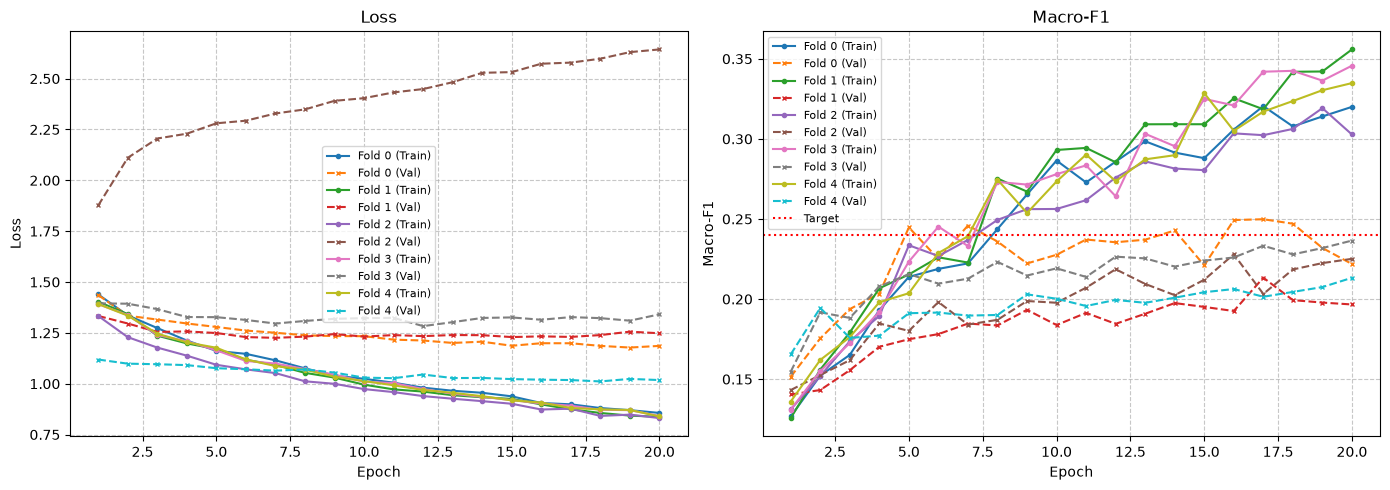

Fold 0: best val macro-F1 0.2498
Fold 1: best val macro-F1 0.2134
Fold 2: best val macro-F1 0.2280
Fold 3: best val macro-F1 0.2365
Fold 4: best val macro-F1 0.2133
Weighted, 10 epochs: 0.2128 ± 0.0194
Weighted, 20 epochs: 0.2282 ± 0.0140


In [24]:
long_results = {}
for fold in range(5):
    print(f'\n--- Fold {fold} ---')
    train_indices = []
    val_indices = []
    for i in range(len(fold_list)):
        if fold_list[i] == fold:
            val_indices.append(i)
        else:
            train_indices.append(i)
    train_loader = DataLoader(Subset(full_ds, train_indices), batch_size=32, shuffle=True)
    val_loader = DataLoader(Subset(full_ds, val_indices), batch_size=64, shuffle=False)

    class_counts = y_true[train_indices].sum(axis=0)
    total = len(train_indices)
    pos_weight = torch.tensor([total / max(class_counts[i], 1) for i in range(len(TECHNIQUES))], dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    torch.manual_seed(SEED)
    model = MemeClassifier().to(device)
    for param in model.encoder.parameters():
        param.requires_grad = False
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
    long_results[f'Fold {fold}'] = run_experiment(model, optimizer, criterion, train_loader, val_loader, epochs=20, name=f'Fold {fold}')

plot_experiments(long_results)
long_scores = []
for name in long_results:
    best = max(long_results[name]['val_f1'])
    long_scores.append(best)
    print(f'{name}: best val macro-F1 {best:.4f}')
print(f'Weighted, 10 epochs: {np.mean(weighted_scores):.4f} ± {np.std(weighted_scores):.4f}')
print(f'Weighted, 20 epochs: {np.mean(long_scores):.4f} ± {np.std(long_scores):.4f}')

Training for 20 epochs over 10 does to look to have raised the mean best validation macro-F1 to `0.225` with +- `0.14` spread (from `0.214` with 10 epochs). It is still however below the `0.24` target. The extra 10 epochs only very marginally improved the score.
However, the training macro-F1 kept climbing significantly, meaning the overfitting became a lot more significant.

We'll keep 20 epochs, but adding more would be meaningless and would just widen the train/val gap even further and likely wouldn't increase the performance.

### Step 12. Tuning the head dropout

We concluded that the frozen model has shown overfitting in the previous step.
Dropout rate in the head we are training is a regularization method that helps prevent overfitting.
Up until now we have been using a dropout rate of 0.3, so we will try to tune it and improve performance - we will try 0.5 and 0.7 dropout rates


--- Dropout 0.5 ---

--- Fold 0 ---


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [Fold 0] Epoch 1/20 — Train: 1.4650 / 0.1242 | Val: 1.4761 / 0.1503
  [Fold 0] Epoch 2/20 — Train: 1.3695 / 0.1493 | Val: 1.3653 / 0.1577
  [Fold 0] Epoch 3/20 — Train: 1.3265 / 0.1556 | Val: 1.3329 / 0.1841
  [Fold 0] Epoch 4/20 — Train: 1.2819 / 0.1741 | Val: 1.3076 / 0.2098
  [Fold 0] Epoch 5/20 — Train: 1.2315 / 0.1967 | Val: 1.2906 / 0.2078
  [Fold 0] Epoch 6/20 — Train: 1.1938 / 0.1951 | Val: 1.2685 / 0.2236
  [Fold 0] Epoch 7/20 — Train: 1.1672 / 0.2022 | Val: 1.2586 / 0.2143
  [Fold 0] Epoch 8/20 — Train: 1.1310 / 0.2186 | Val: 1.2487 / 0.2383
  [Fold 0] Epoch 9/20 — Train: 1.0920 / 0.2351 | Val: 1.2433 / 0.2161
  [Fold 0] Epoch 10/20 — Train: 1.0778 / 0.2360 | Val: 1.2402 / 0.2231
  [Fold 0] Epoch 11/20 — Train: 1.0421 / 0.2458 | Val: 1.2317 / 0.2331
  [Fold 0] Epoch 12/20 — Train: 1.0251 / 0.2526 | Val: 1.2264 / 0.2371
  [Fold 0] Epoch 13/20 — Train: 1.0011 / 0.2618 | Val: 1.2189 / 0.2291
  [Fold 0] Epoch 14/20 — Train: 1.0041 / 0.2658 | Val: 1.2222 / 0.2294
  [Fold 0] Epoc

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [Fold 3] Epoch 1/20 — Train: 1.3932 / 0.1281 | Val: 1.4799 / 0.1668
  [Fold 3] Epoch 2/20 — Train: 1.4092 / 0.1561 | Val: 1.4894 / 0.1928
  [Fold 3] Epoch 3/20 — Train: 1.2954 / 0.1624 | Val: 1.4368 / 0.1911
  [Fold 3] Epoch 4/20 — Train: 1.2499 / 0.1713 | Val: 1.3781 / 0.1978
  [Fold 3] Epoch 5/20 — Train: 1.2136 / 0.1907 | Val: 1.3611 / 0.2059
  [Fold 3] Epoch 6/20 — Train: 1.1589 / 0.2183 | Val: 1.3367 / 0.2105
  [Fold 3] Epoch 7/20 — Train: 1.1551 / 0.2129 | Val: 1.3122 / 0.2096
  [Fold 3] Epoch 8/20 — Train: 1.1278 / 0.2188 | Val: 1.3072 / 0.2235
  [Fold 3] Epoch 9/20 — Train: 1.0958 / 0.2341 | Val: 1.3094 / 0.2206
  [Fold 3] Epoch 10/20 — Train: 1.0467 / 0.2459 | Val: 1.3038 / 0.2191
  [Fold 3] Epoch 11/20 — Train: 1.0593 / 0.2449 | Val: 1.3093 / 0.2126
  [Fold 3] Epoch 12/20 — Train: 1.0366 / 0.2410 | Val: 1.2634 / 0.2291
  [Fold 3] Epoch 13/20 — Train: 1.0157 / 0.2591 | Val: 1.2704 / 0.2179
  [Fold 3] Epoch 14/20 — Train: 0.9901 / 0.2577 | Val: 1.2951 / 0.2244
  [Fold 3] Epoc

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [Fold 4] Epoch 1/20 — Train: 1.3907 / 0.1339 | Val: 1.1121 / 0.1521
  [Fold 4] Epoch 2/20 — Train: 1.4045 / 0.1519 | Val: 1.0936 / 0.1768
  [Fold 4] Epoch 3/20 — Train: 1.2952 / 0.1641 | Val: 1.0902 / 0.1802
  [Fold 4] Epoch 4/20 — Train: 1.2394 / 0.1851 | Val: 1.0877 / 0.1730
  [Fold 4] Epoch 5/20 — Train: 1.2214 / 0.1887 | Val: 1.0746 / 0.1906
  [Fold 4] Epoch 6/20 — Train: 1.1677 / 0.2094 | Val: 1.0700 / 0.1875
  [Fold 4] Epoch 7/20 — Train: 1.1437 / 0.2157 | Val: 1.0617 / 0.1817
  [Fold 4] Epoch 8/20 — Train: 1.1258 / 0.2231 | Val: 1.0694 / 0.1837
  [Fold 4] Epoch 9/20 — Train: 1.0855 / 0.2303 | Val: 1.0584 / 0.1961
  [Fold 4] Epoch 10/20 — Train: 1.0479 / 0.2503 | Val: 1.0376 / 0.1958
  [Fold 4] Epoch 11/20 — Train: 1.0419 / 0.2634 | Val: 1.0319 / 0.1932
  [Fold 4] Epoch 12/20 — Train: 1.0186 / 0.2525 | Val: 1.0512 / 0.1984
  [Fold 4] Epoch 13/20 — Train: 1.0033 / 0.2571 | Val: 1.0344 / 0.1931
  [Fold 4] Epoch 14/20 — Train: 0.9879 / 0.2648 | Val: 1.0358 / 0.1940
  [Fold 4] Epoc

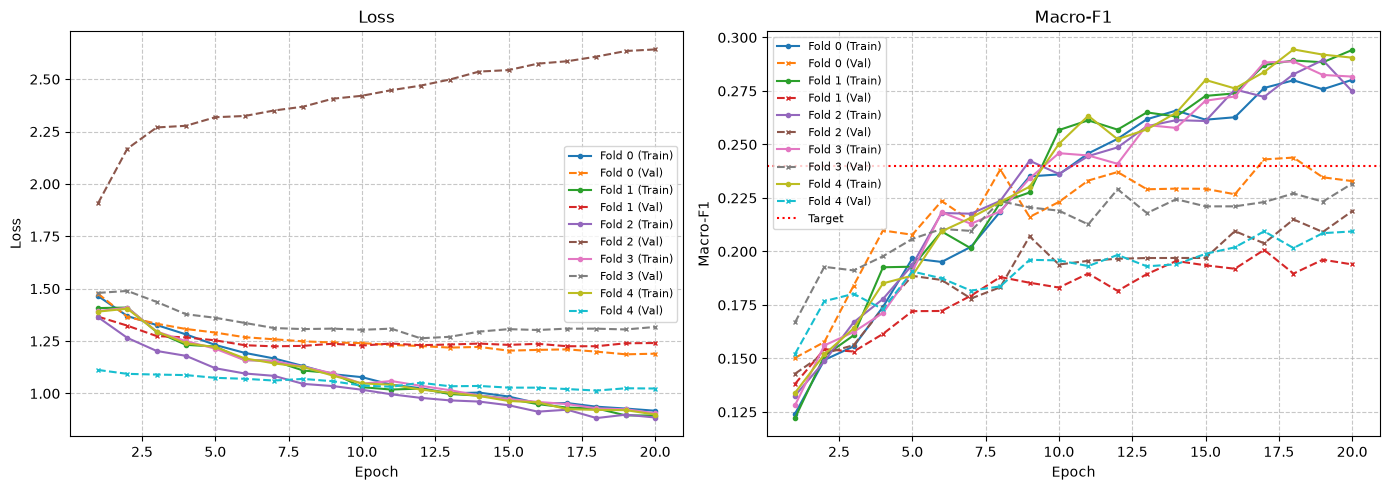


--- Dropout 0.7 ---

--- Fold 0 ---


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [Fold 0] Epoch 1/20 — Train: 1.5162 / 0.1162 | Val: 1.5535 / 0.1190
  [Fold 0] Epoch 2/20 — Train: 1.4668 / 0.1430 | Val: 1.4506 / 0.1767
  [Fold 0] Epoch 3/20 — Train: 1.4133 / 0.1449 | Val: 1.4066 / 0.1793
  [Fold 0] Epoch 4/20 — Train: 1.3747 / 0.1626 | Val: 1.3715 / 0.2077
  [Fold 0] Epoch 5/20 — Train: 1.3472 / 0.1706 | Val: 1.3408 / 0.2169
  [Fold 0] Epoch 6/20 — Train: 1.3255 / 0.1699 | Val: 1.3054 / 0.2120
  [Fold 0] Epoch 7/20 — Train: 1.2979 / 0.1746 | Val: 1.2860 / 0.2109
  [Fold 0] Epoch 8/20 — Train: 1.2164 / 0.1904 | Val: 1.2719 / 0.2218
  [Fold 0] Epoch 9/20 — Train: 1.1898 / 0.2005 | Val: 1.2632 / 0.2158
  [Fold 0] Epoch 10/20 — Train: 1.1804 / 0.2019 | Val: 1.2563 / 0.2264
  [Fold 0] Epoch 11/20 — Train: 1.1355 / 0.2018 | Val: 1.2528 / 0.2229
  [Fold 0] Epoch 12/20 — Train: 1.1032 / 0.2100 | Val: 1.2457 / 0.2247
  [Fold 0] Epoch 13/20 — Train: 1.0854 / 0.2182 | Val: 1.2400 / 0.2174
  [Fold 0] Epoch 14/20 — Train: 1.0986 / 0.2225 | Val: 1.2479 / 0.2153
  [Fold 0] Epoc

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [Fold 3] Epoch 1/20 — Train: 1.4304 / 0.1276 | Val: 1.5714 / 0.1735
  [Fold 3] Epoch 2/20 — Train: 1.5523 / 0.1402 | Val: 1.6223 / 0.1817
  [Fold 3] Epoch 3/20 — Train: 1.4119 / 0.1491 | Val: 1.5858 / 0.2071
  [Fold 3] Epoch 4/20 — Train: 1.3287 / 0.1652 | Val: 1.5181 / 0.2191
  [Fold 3] Epoch 5/20 — Train: 1.3108 / 0.1691 | Val: 1.4804 / 0.2301
  [Fold 3] Epoch 6/20 — Train: 1.3182 / 0.1782 | Val: 1.4376 / 0.2169
  [Fold 3] Epoch 7/20 — Train: 1.2298 / 0.1853 | Val: 1.3908 / 0.2085
  [Fold 3] Epoch 8/20 — Train: 1.2755 / 0.1844 | Val: 1.3586 / 0.2162
  [Fold 3] Epoch 9/20 — Train: 1.1918 / 0.1966 | Val: 1.3347 / 0.2083
  [Fold 3] Epoch 10/20 — Train: 1.1789 / 0.2045 | Val: 1.3102 / 0.2104
  [Fold 3] Epoch 11/20 — Train: 1.1699 / 0.1999 | Val: 1.3069 / 0.2080
  [Fold 3] Epoch 12/20 — Train: 1.1475 / 0.2070 | Val: 1.2788 / 0.2181
  [Fold 3] Epoch 13/20 — Train: 1.1365 / 0.2095 | Val: 1.2710 / 0.2129
  [Fold 3] Epoch 14/20 — Train: 1.0802 / 0.2175 | Val: 1.2852 / 0.2206
  [Fold 3] Epoc

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [Fold 4] Epoch 1/20 — Train: 1.4193 / 0.1333 | Val: 1.1012 / 0.1443
  [Fold 4] Epoch 2/20 — Train: 1.5235 / 0.1430 | Val: 1.0848 / 0.1598
  [Fold 4] Epoch 3/20 — Train: 1.4082 / 0.1532 | Val: 1.0780 / 0.1826
  [Fold 4] Epoch 4/20 — Train: 1.2992 / 0.1617 | Val: 1.0753 / 0.1720
  [Fold 4] Epoch 5/20 — Train: 1.3222 / 0.1715 | Val: 1.0721 / 0.1964
  [Fold 4] Epoch 6/20 — Train: 1.3023 / 0.1901 | Val: 1.0709 / 0.2006
  [Fold 4] Epoch 7/20 — Train: 1.2356 / 0.1938 | Val: 1.0632 / 0.1789
  [Fold 4] Epoch 8/20 — Train: 1.2490 / 0.1928 | Val: 1.0680 / 0.1848
  [Fold 4] Epoch 9/20 — Train: 1.1758 / 0.2019 | Val: 1.0623 / 0.1953
  [Fold 4] Epoch 10/20 — Train: 1.1586 / 0.2085 | Val: 1.0443 / 0.1915
  [Fold 4] Epoch 11/20 — Train: 1.1574 / 0.2090 | Val: 1.0359 / 0.1897
  [Fold 4] Epoch 12/20 — Train: 1.1280 / 0.2201 | Val: 1.0514 / 0.1923
  [Fold 4] Epoch 13/20 — Train: 1.0974 / 0.2196 | Val: 1.0424 / 0.1889
  [Fold 4] Epoch 14/20 — Train: 1.0766 / 0.2302 | Val: 1.0434 / 0.1892
  [Fold 4] Epoc

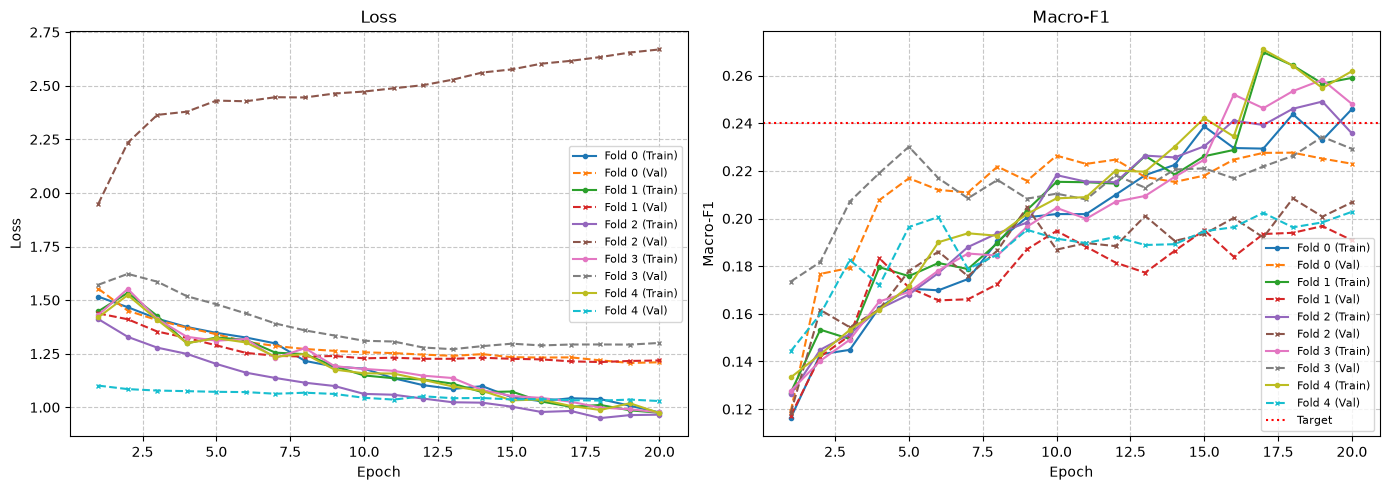

Dropout 0.3: 0.2282 ± 0.0140
Dropout 0.5: 0.2209 ± 0.0154
Dropout 0.7: 0.2140 ± 0.0145


In [26]:
dropout_scores = {}
for dropout_rate in [0.5, 0.7]:
    print(f'\n--- Dropout {dropout_rate} ---')
    rate_results = {}
    for fold in range(5):
        print(f'\n--- Fold {fold} ---')
        train_indices = []
        val_indices = []
        for i in range(len(fold_list)):
            if fold_list[i] == fold:
                val_indices.append(i)
            else:
                train_indices.append(i)
        train_loader = DataLoader(Subset(full_ds, train_indices), batch_size=32, shuffle=True)
        val_loader = DataLoader(Subset(full_ds, val_indices), batch_size=64, shuffle=False)

        class_counts = y_true[train_indices].sum(axis=0)
        total = len(train_indices)
        pos_weight = torch.tensor([total / max(class_counts[i], 1) for i in range(len(TECHNIQUES))], dtype=torch.float32).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        torch.manual_seed(SEED)
        model = MemeClassifier().to(device)
        model.head[0].p = dropout_rate
        for param in model.encoder.parameters():
            param.requires_grad = False
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
        rate_results[f'Fold {fold}'] = run_experiment(model, optimizer, criterion, train_loader, val_loader, epochs=20, name=f'Fold {fold}')

    plot_experiments(rate_results)
    rate_scores = []
    for name in rate_results:
        rate_scores.append(max(rate_results[name]['val_f1']))
    dropout_scores[dropout_rate] = rate_scores

print(f'Dropout 0.3: {np.mean(long_scores):.4f} ± {np.std(long_scores):.4f}')
for dropout_rate in dropout_scores:
    print(f'Dropout {dropout_rate}: {np.mean(dropout_scores[dropout_rate]):.4f} ± {np.std(dropout_scores[dropout_rate]):.4f}')

Increasing the dropout rate has resulted in a decreased mean best validation macro-F1 score.
To compare:
- 0.3 dropout rate: `0.228`
- 0.5 dropout rate: `0.221`
- 0.7 dropout rate: `0.214`

The train/val gap did shrink, but this doesn't do us any good, since the validation decreased as well.

We will keep dropout at 0.3, since less overfitting did not help.
The frozen model may be limited by what frozen DistilBERT can express, so we will try to address it by using LoRA.

### Step 13. LoRA

The model with frozen DistilBERT looks to have hit the performance ceiling. Validation macro-F1 barely reaches `0.225`, while the training is still climbing.

Up to now, only the model head on top of frozen DistilBERT was learning, while DistilBERT itself was not changing. We will now use LoRA to let this encoder tune itself towards to the meme texts without retraining the huge model.

We'll use the LoRA settings from the labs, as well as the optimizer, while everything else will remain unchanged from the previous step. We will use learning rate of `1e-4` (like in the lab), which is 10 times less than the one we used for the frozen model (lr of `1e-3`).


--- Fold 0 ---


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


trainable params: 147,456 || all params: 66,510,336 || trainable%: 0.2217
  [Fold 0] Epoch 1/20 — Train: 1.3549 / 0.0900 | Val: 1.4504 / 0.0758
  [Fold 0] Epoch 2/20 — Train: 1.3358 / 0.1245 | Val: 1.4311 / 0.1362
  [Fold 0] Epoch 3/20 — Train: 1.3083 / 0.1403 | Val: 1.4135 / 0.1511
  [Fold 0] Epoch 4/20 — Train: 1.3003 / 0.1487 | Val: 1.3974 / 0.1619
  [Fold 0] Epoch 5/20 — Train: 1.3004 / 0.1533 | Val: 1.3846 / 0.1766
  [Fold 0] Epoch 6/20 — Train: 1.2837 / 0.1519 | Val: 1.3687 / 0.1715
  [Fold 0] Epoch 7/20 — Train: 1.2718 / 0.1534 | Val: 1.3508 / 0.1769
  [Fold 0] Epoch 8/20 — Train: 1.2423 / 0.1630 | Val: 1.3329 / 0.1722
  [Fold 0] Epoch 9/20 — Train: 1.2110 / 0.1683 | Val: 1.3178 / 0.1815
  [Fold 0] Epoch 10/20 — Train: 1.1869 / 0.1707 | Val: 1.2979 / 0.1878
  [Fold 0] Epoch 11/20 — Train: 1.1510 / 0.1866 | Val: 1.2864 / 0.1938
  [Fold 0] Epoch 12/20 — Train: 1.1227 / 0.1932 | Val: 1.2737 / 0.1984
  [Fold 0] Epoch 13/20 — Train: 1.0977 / 0.2021 | Val: 1.2660 / 0.2091
  [Fold 0] E

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [Fold 3] Epoch 1/20 — Train: 1.3387 / 0.0980 | Val: 1.4478 / 0.0895
  [Fold 3] Epoch 2/20 — Train: 1.3359 / 0.1259 | Val: 1.4344 / 0.1435
  [Fold 3] Epoch 3/20 — Train: 1.3078 / 0.1369 | Val: 1.4187 / 0.1725
  [Fold 3] Epoch 4/20 — Train: 1.2962 / 0.1483 | Val: 1.4064 / 0.1725
  [Fold 3] Epoch 5/20 — Train: 1.2867 / 0.1557 | Val: 1.3975 / 0.1734
  [Fold 3] Epoch 6/20 — Train: 1.2721 / 0.1620 | Val: 1.3856 / 0.1716
  [Fold 3] Epoch 7/20 — Train: 1.2547 / 0.1565 | Val: 1.3771 / 0.1660
  [Fold 3] Epoch 8/20 — Train: 1.2493 / 0.1640 | Val: 1.3560 / 0.1706
  [Fold 3] Epoch 9/20 — Train: 1.1934 / 0.1716 | Val: 1.3496 / 0.1663
  [Fold 3] Epoch 10/20 — Train: 1.1664 / 0.1792 | Val: 1.3294 / 0.1734
  [Fold 3] Epoch 11/20 — Train: 1.1402 / 0.1854 | Val: 1.3163 / 0.1810
  [Fold 3] Epoch 12/20 — Train: 1.0981 / 0.1927 | Val: 1.3106 / 0.1866
  [Fold 3] Epoch 13/20 — Train: 1.0695 / 0.2092 | Val: 1.3122 / 0.1998
  [Fold 3] Epoch 14/20 — Train: 1.0441 / 0.2178 | Val: 1.3080 / 0.2104
  [Fold 3] Epoc

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [Fold 4] Epoch 1/20 — Train: 1.3457 / 0.0977 | Val: 1.1869 / 0.0914
  [Fold 4] Epoch 2/20 — Train: 1.3398 / 0.1216 | Val: 1.1741 / 0.1434
  [Fold 4] Epoch 3/20 — Train: 1.3040 / 0.1481 | Val: 1.1663 / 0.1471
  [Fold 4] Epoch 4/20 — Train: 1.2913 / 0.1494 | Val: 1.1619 / 0.1473
  [Fold 4] Epoch 5/20 — Train: 1.2793 / 0.1567 | Val: 1.1574 / 0.1473
  [Fold 4] Epoch 6/20 — Train: 1.2752 / 0.1533 | Val: 1.1508 / 0.1522
  [Fold 4] Epoch 7/20 — Train: 1.2423 / 0.1612 | Val: 1.1412 / 0.1542
  [Fold 4] Epoch 8/20 — Train: 1.2349 / 0.1637 | Val: 1.1329 / 0.1586
  [Fold 4] Epoch 9/20 — Train: 1.1940 / 0.1741 | Val: 1.1160 / 0.1624
  [Fold 4] Epoch 10/20 — Train: 1.1641 / 0.1781 | Val: 1.0989 / 0.1693
  [Fold 4] Epoch 11/20 — Train: 1.1257 / 0.1891 | Val: 1.0838 / 0.1684
  [Fold 4] Epoch 12/20 — Train: 1.0942 / 0.2043 | Val: 1.0820 / 0.1770
  [Fold 4] Epoch 13/20 — Train: 1.0681 / 0.2132 | Val: 1.0606 / 0.1811
  [Fold 4] Epoch 14/20 — Train: 1.0426 / 0.2235 | Val: 1.0570 / 0.1852
  [Fold 4] Epoc

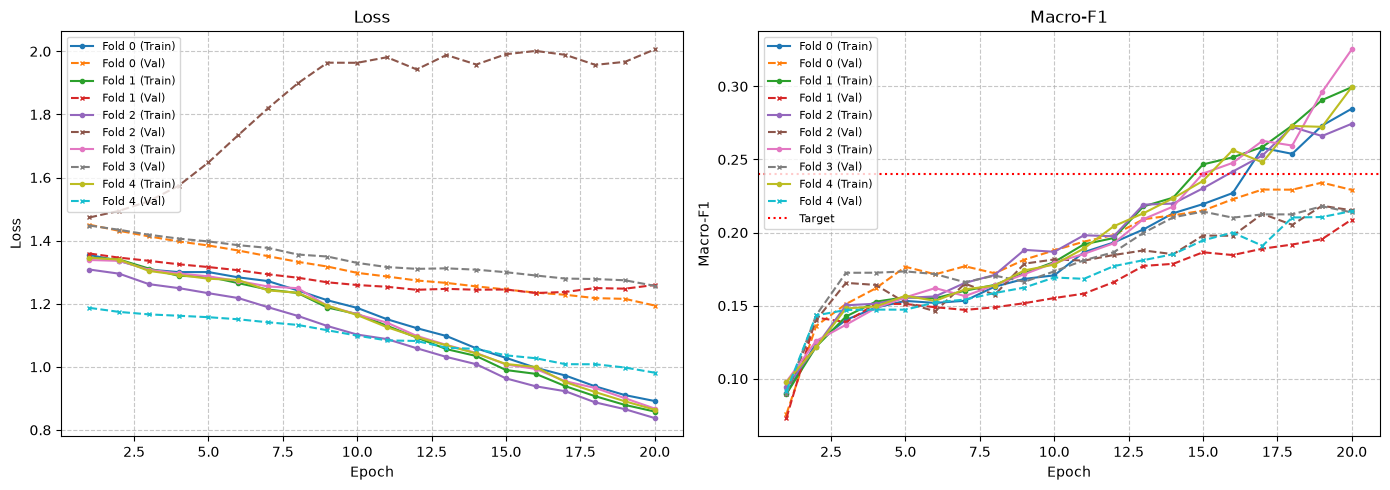

Fold 0: best val macro-F1 0.2342
Fold 1: best val macro-F1 0.2089
Fold 2: best val macro-F1 0.2183
Fold 3: best val macro-F1 0.2180
Fold 4: best val macro-F1 0.2147
Frozen, 20 epochs: 0.2282 ± 0.0140
LoRA, 20 epochs:   0.2188 ± 0.0084


In [25]:
from peft import LoraConfig, get_peft_model, TaskType

lora_results = {}
for fold in range(5):
    print(f'\n--- Fold {fold} ---')
    train_indices = []
    val_indices = []
    for i in range(len(fold_list)):
        if fold_list[i] == fold:
            val_indices.append(i)
        else:
            train_indices.append(i)
    train_loader = DataLoader(Subset(full_ds, train_indices), batch_size=32, shuffle=True)
    val_loader = DataLoader(Subset(full_ds, val_indices), batch_size=64, shuffle=False)

    class_counts = y_true[train_indices].sum(axis=0)
    total = len(train_indices)
    pos_weight = torch.tensor([total / max(class_counts[i], 1) for i in range(len(TECHNIQUES))], dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    torch.manual_seed(SEED)
    model = MemeClassifier().to(device)
    lora_config = LoraConfig(
        task_type=TaskType.FEATURE_EXTRACTION,
        r=8,
        lora_alpha=16,
        lora_dropout=0.1,
        target_modules=['q_lin', 'v_lin'],
    )
    model.encoder = get_peft_model(model.encoder, lora_config)
    if fold == 0:
        model.encoder.print_trainable_parameters()
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=0.01)
    lora_results[f'Fold {fold}'] = run_experiment(model, optimizer, criterion, train_loader, val_loader, epochs=20, name=f'Fold {fold}')

plot_experiments(lora_results)
lora_scores = []
for name in lora_results:
    best = max(lora_results[name]['val_f1'])
    lora_scores.append(best)
    print(f'{name}: best val macro-F1 {best:.4f}')
print(f'Frozen, 20 epochs: {np.mean(long_scores):.4f} ± {np.std(long_scores):.4f}')
print(f'LoRA, 20 epochs:   {np.mean(lora_scores):.4f} ± {np.std(lora_scores):.4f}')

LoRA has reached the mean best validation macro-F1 score of `0.219` (with spread of +- `0.008`). This value is a little below the frozen model's `0.228`. The difference is within the spread across folds, so the two models are essentially tied.

However, if we look at the macro-F1 graph, we can see that even at epoch 20 LoRA is still clearly improving and the validation macro-F1 is still climbing decently steeply at epoch 20 in all 5 folds. At that point the frozen model already flattens out or nearly flattens out.

### Step 14. Fine-tuning LoRA learning rate value

As we saw from the graphs above, at epoch 20, LoRA's validation macro-F1 was still climbing rather steeply. Since we were using a learning rate value 10 times less than the one we used for the frozen mode, LoRA could be learning too slowly.
We'll try 2 other values on top of `1e-4` we tried in the previous step - `3e-4` and `1e-3`.


--- LoRA lr=0.0003 ---

--- Fold 0 ---


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [Fold 0] Epoch 1/20 — Train: 1.3660 / 0.1143 | Val: 1.4260 / 0.1465
  [Fold 0] Epoch 2/20 — Train: 1.3147 / 0.1465 | Val: 1.3841 / 0.1712
  [Fold 0] Epoch 3/20 — Train: 1.2714 / 0.1537 | Val: 1.3488 / 0.2137
  [Fold 0] Epoch 4/20 — Train: 1.2342 / 0.1675 | Val: 1.3072 / 0.1796
  [Fold 0] Epoch 5/20 — Train: 1.1847 / 0.1973 | Val: 1.2650 / 0.1857
  [Fold 0] Epoch 6/20 — Train: 1.0947 / 0.2011 | Val: 1.2343 / 0.2127
  [Fold 0] Epoch 7/20 — Train: 1.0039 / 0.2474 | Val: 1.2020 / 0.2274
  [Fold 0] Epoch 8/20 — Train: 0.9399 / 0.2496 | Val: 1.1949 / 0.2279
  [Fold 0] Epoch 9/20 — Train: 0.8525 / 0.3019 | Val: 1.1754 / 0.2458
  [Fold 0] Epoch 10/20 — Train: 0.7928 / 0.3260 | Val: 1.2071 / 0.2546
  [Fold 0] Epoch 11/20 — Train: 0.7351 / 0.3520 | Val: 1.2004 / 0.2514
  [Fold 0] Epoch 12/20 — Train: 0.6858 / 0.3755 | Val: 1.2178 / 0.2556
  [Fold 0] Epoch 13/20 — Train: 0.6466 / 0.3956 | Val: 1.2284 / 0.2564
  [Fold 0] Epoch 14/20 — Train: 0.6108 / 0.4252 | Val: 1.2366 / 0.2479
  [Fold 0] Epoc

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [Fold 3] Epoch 1/20 — Train: 1.3366 / 0.1205 | Val: 1.4456 / 0.1336
  [Fold 3] Epoch 2/20 — Train: 1.3122 / 0.1492 | Val: 1.4204 / 0.1625
  [Fold 3] Epoch 3/20 — Train: 1.2643 / 0.1656 | Val: 1.3890 / 0.1689
  [Fold 3] Epoch 4/20 — Train: 1.2183 / 0.1737 | Val: 1.3481 / 0.1664
  [Fold 3] Epoch 5/20 — Train: 1.1383 / 0.1888 | Val: 1.3324 / 0.2020
  [Fold 3] Epoch 6/20 — Train: 1.0538 / 0.2405 | Val: 1.3063 / 0.2021
  [Fold 3] Epoch 7/20 — Train: 0.9651 / 0.2381 | Val: 1.3053 / 0.2167
  [Fold 3] Epoch 8/20 — Train: 0.9021 / 0.2720 | Val: 1.2539 / 0.2217
  [Fold 3] Epoch 9/20 — Train: 0.8258 / 0.3136 | Val: 1.3121 / 0.2467
  [Fold 3] Epoch 10/20 — Train: 0.7580 / 0.3670 | Val: 1.2877 / 0.2285
  [Fold 3] Epoch 11/20 — Train: 0.7088 / 0.3700 | Val: 1.3504 / 0.2541
  [Fold 3] Epoch 12/20 — Train: 0.6610 / 0.3793 | Val: 1.4448 / 0.2503
  [Fold 3] Epoch 13/20 — Train: 0.6342 / 0.4151 | Val: 1.4387 / 0.2536
  [Fold 3] Epoch 14/20 — Train: 0.6024 / 0.4310 | Val: 1.4573 / 0.2604
  [Fold 3] Epoc

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [Fold 4] Epoch 1/20 — Train: 1.3410 / 0.1245 | Val: 1.1592 / 0.1509
  [Fold 4] Epoch 2/20 — Train: 1.3177 / 0.1520 | Val: 1.1464 / 0.1515
  [Fold 4] Epoch 3/20 — Train: 1.2628 / 0.1667 | Val: 1.1377 / 0.1616
  [Fold 4] Epoch 4/20 — Train: 1.2061 / 0.1746 | Val: 1.1139 / 0.1576
  [Fold 4] Epoch 5/20 — Train: 1.1378 / 0.1939 | Val: 1.0720 / 0.1785
  [Fold 4] Epoch 6/20 — Train: 1.0649 / 0.2232 | Val: 1.0364 / 0.1716
  [Fold 4] Epoch 7/20 — Train: 0.9592 / 0.2433 | Val: 1.0038 / 0.2061
  [Fold 4] Epoch 8/20 — Train: 0.8962 / 0.2662 | Val: 0.9882 / 0.2013
  [Fold 4] Epoch 9/20 — Train: 0.8128 / 0.2976 | Val: 0.9522 / 0.2143
  [Fold 4] Epoch 10/20 — Train: 0.7610 / 0.3189 | Val: 0.9522 / 0.2348
  [Fold 4] Epoch 11/20 — Train: 0.7019 / 0.3666 | Val: 0.9789 / 0.2547
  [Fold 4] Epoch 12/20 — Train: 0.6580 / 0.3954 | Val: 0.9426 / 0.2254
  [Fold 4] Epoch 13/20 — Train: 0.6257 / 0.3875 | Val: 0.9878 / 0.2477
  [Fold 4] Epoch 14/20 — Train: 0.5901 / 0.4201 | Val: 1.0062 / 0.2578
  [Fold 4] Epoc

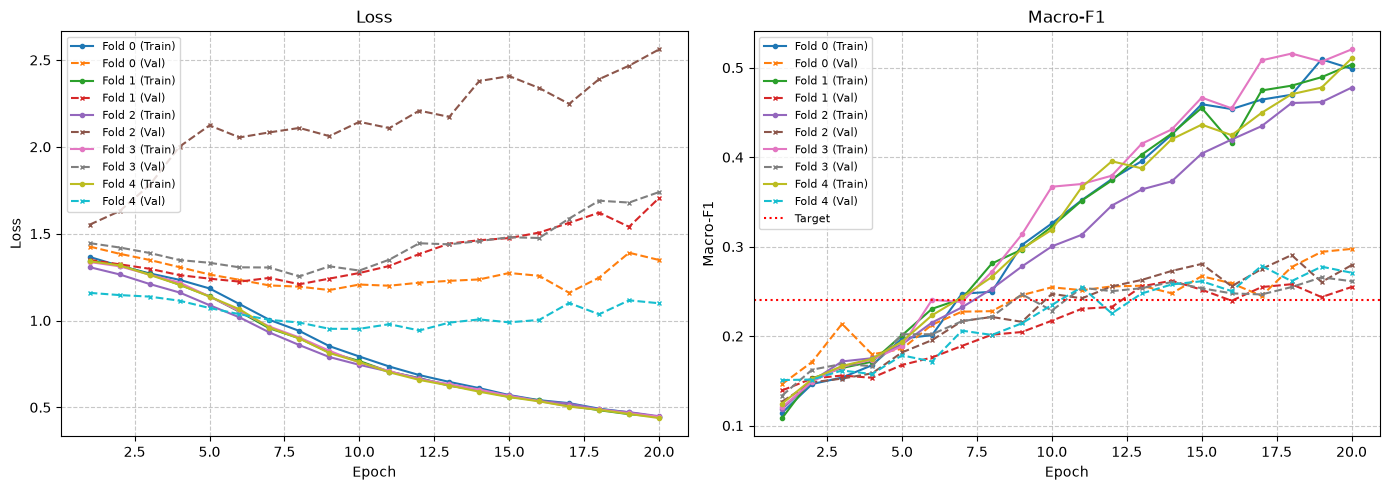


--- LoRA lr=0.001 ---

--- Fold 0 ---


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [Fold 0] Epoch 1/20 — Train: 1.4214 / 0.1275 | Val: 1.3816 / 0.1536
  [Fold 0] Epoch 2/20 — Train: 1.2827 / 0.1589 | Val: 1.3249 / 0.1760
  [Fold 0] Epoch 3/20 — Train: 1.1659 / 0.2368 | Val: 1.2350 / 0.1877
  [Fold 0] Epoch 4/20 — Train: 1.0118 / 0.2165 | Val: 1.2001 / 0.2326
  [Fold 0] Epoch 5/20 — Train: 0.8424 / 0.2727 | Val: 1.1714 / 0.2305
  [Fold 0] Epoch 6/20 — Train: 0.6804 / 0.3535 | Val: 1.2988 / 0.2607
  [Fold 0] Epoch 7/20 — Train: 0.5695 / 0.4317 | Val: 1.2612 / 0.2362
  [Fold 0] Epoch 8/20 — Train: 0.4905 / 0.4557 | Val: 1.4184 / 0.2557
  [Fold 0] Epoch 9/20 — Train: 0.4249 / 0.5046 | Val: 1.5147 / 0.2721
  [Fold 0] Epoch 10/20 — Train: 0.3789 / 0.5583 | Val: 1.7653 / 0.2758
  [Fold 0] Epoch 11/20 — Train: 0.3505 / 0.5759 | Val: 1.4635 / 0.2627
  [Fold 0] Epoch 12/20 — Train: 0.3145 / 0.5998 | Val: 2.0188 / 0.2781
  [Fold 0] Epoch 13/20 — Train: 0.2758 / 0.6524 | Val: 1.9117 / 0.2765
  [Fold 0] Epoch 14/20 — Train: 0.2495 / 0.6983 | Val: 2.3256 / 0.2752
  [Fold 0] Epoc

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [Fold 3] Epoch 1/20 — Train: 1.3522 / 0.1352 | Val: 1.4257 / 0.1839
  [Fold 3] Epoch 2/20 — Train: 1.2699 / 0.1778 | Val: 1.3602 / 0.1637
  [Fold 3] Epoch 3/20 — Train: 1.1042 / 0.2330 | Val: 1.3412 / 0.2045
  [Fold 3] Epoch 4/20 — Train: 0.8777 / 0.2807 | Val: 1.3589 / 0.2309
  [Fold 3] Epoch 5/20 — Train: 0.7008 / 0.3393 | Val: 1.5125 / 0.2467
  [Fold 3] Epoch 6/20 — Train: 0.5964 / 0.3918 | Val: 1.5097 / 0.2497
  [Fold 3] Epoch 7/20 — Train: 0.5115 / 0.4668 | Val: 1.8724 / 0.2660
  [Fold 3] Epoch 8/20 — Train: 0.4505 / 0.4898 | Val: 1.8984 / 0.2673
  [Fold 3] Epoch 9/20 — Train: 0.4076 / 0.5153 | Val: 1.8401 / 0.2614
  [Fold 3] Epoch 10/20 — Train: 0.3646 / 0.5876 | Val: 1.9130 / 0.2779
  [Fold 3] Epoch 11/20 — Train: 0.3332 / 0.5854 | Val: 2.4381 / 0.2910
  [Fold 3] Epoch 12/20 — Train: 0.3023 / 0.6066 | Val: 2.3935 / 0.2837
  [Fold 3] Epoch 13/20 — Train: 0.2744 / 0.6773 | Val: 2.5889 / 0.2725
  [Fold 3] Epoch 14/20 — Train: 0.2510 / 0.6679 | Val: 2.6904 / 0.2942
  [Fold 3] Epoc

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [Fold 4] Epoch 1/20 — Train: 1.3454 / 0.1339 | Val: 1.1318 / 0.1549
  [Fold 4] Epoch 2/20 — Train: 1.2859 / 0.1606 | Val: 1.1213 / 0.1631
  [Fold 4] Epoch 3/20 — Train: 1.1109 / 0.2343 | Val: 1.0529 / 0.1716
  [Fold 4] Epoch 4/20 — Train: 0.9038 / 0.2543 | Val: 1.0411 / 0.2015
  [Fold 4] Epoch 5/20 — Train: 0.7479 / 0.3247 | Val: 1.0790 / 0.2389
  [Fold 4] Epoch 6/20 — Train: 0.6301 / 0.3746 | Val: 1.0358 / 0.2446
  [Fold 4] Epoch 7/20 — Train: 0.5263 / 0.4311 | Val: 1.1153 / 0.2339
  [Fold 4] Epoch 8/20 — Train: 0.4713 / 0.4888 | Val: 1.2689 / 0.2393
  [Fold 4] Epoch 9/20 — Train: 0.4091 / 0.5142 | Val: 1.2232 / 0.2446
  [Fold 4] Epoch 10/20 — Train: 0.3709 / 0.5788 | Val: 1.3584 / 0.2425
  [Fold 4] Epoch 11/20 — Train: 0.3300 / 0.6248 | Val: 1.5708 / 0.2317
  [Fold 4] Epoch 12/20 — Train: 0.2931 / 0.6656 | Val: 1.4928 / 0.2682
  [Fold 4] Epoch 13/20 — Train: 0.2702 / 0.6394 | Val: 1.7121 / 0.2347
  [Fold 4] Epoch 14/20 — Train: 0.2464 / 0.6804 | Val: 1.7552 / 0.2550
  [Fold 4] Epoc

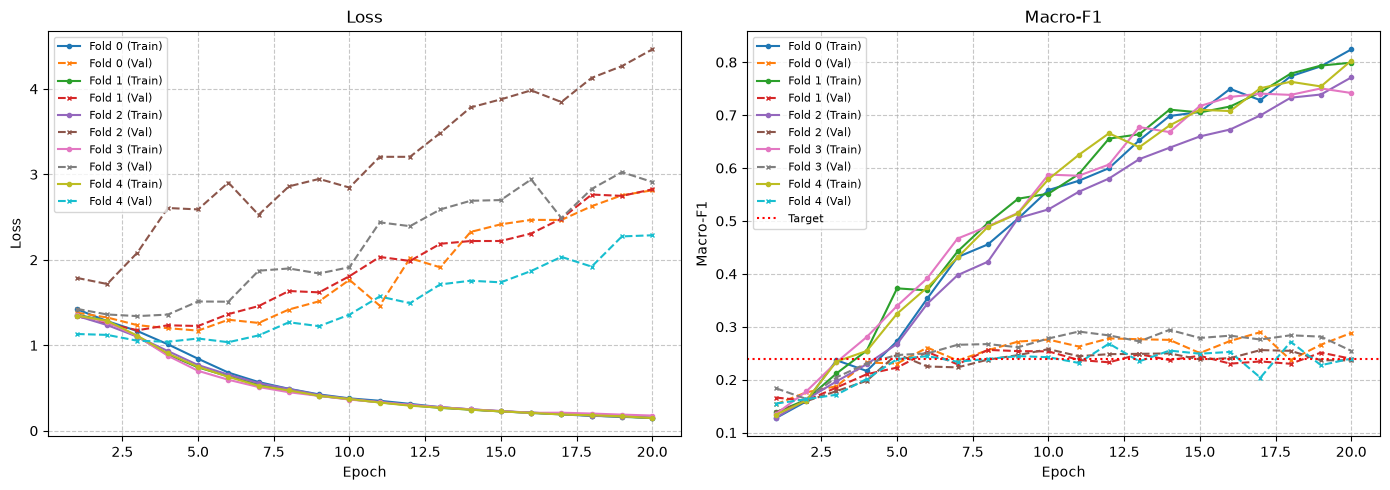

Frozen (dropout 0.3): 0.2282 ± 0.0140
LoRA lr=0.0001:       0.2188 ± 0.0084
LoRA lr=0.0003:       0.2789 ± 0.0137
LoRA lr=0.001:       0.2740 ± 0.0158


In [27]:
lora_lr_scores = {}
for lr in [3e-4, 1e-3]:
    print(f'\n--- LoRA lr={lr} ---')
    lr_results = {}
    for fold in range(5):
        print(f'\n--- Fold {fold} ---')
        train_indices = []
        val_indices = []
        for i in range(len(fold_list)):
            if fold_list[i] == fold:
                val_indices.append(i)
            else:
                train_indices.append(i)
        train_loader = DataLoader(Subset(full_ds, train_indices), batch_size=32, shuffle=True)
        val_loader = DataLoader(Subset(full_ds, val_indices), batch_size=64, shuffle=False)

        class_counts = y_true[train_indices].sum(axis=0)
        total = len(train_indices)
        pos_weight = torch.tensor([total / max(class_counts[i], 1) for i in range(len(TECHNIQUES))], dtype=torch.float32).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        torch.manual_seed(SEED)
        model = MemeClassifier().to(device)
        lora_config = LoraConfig(
            task_type=TaskType.FEATURE_EXTRACTION,
            r=8,
            lora_alpha=16,
            lora_dropout=0.1,
            target_modules=['q_lin', 'v_lin'],
        )
        model.encoder = get_peft_model(model.encoder, lora_config)
        optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=0.01)
        lr_results[f'Fold {fold}'] = run_experiment(model, optimizer, criterion, train_loader, val_loader, epochs=20, name=f'Fold {fold}')

    plot_experiments(lr_results)
    rate_scores = []
    for name in lr_results:
        rate_scores.append(max(lr_results[name]['val_f1']))
    lora_lr_scores[lr] = rate_scores

print(f'Frozen (dropout 0.3): {np.mean(long_scores):.4f} ± {np.std(long_scores):.4f}')
print(f'LoRA lr=0.0001:       {np.mean(lora_scores):.4f} ± {np.std(lora_scores):.4f}')
for lr in lora_lr_scores:
    print(f'LoRA lr={lr}:       {np.mean(lora_lr_scores[lr]):.4f} ± {np.std(lora_lr_scores[lr]):.4f}')

Increasing learning rate did wonders. With `3e-4`, LoRA was able to reach a mean best val macro-F1 of `0.2789` (with a spread of +- `0.014`) and with `1e-3` it reaches `0.274` (+-`0.016`), which are both above the `0.24` target we set in the beginning. It also comfortably beats the frozen model (with score of `0.228`). Looks like with the learning rate value from the previous step (`1e-4`) the model was just learning too slow.

There are some differences between the two learning rates. `1e-3` resulted in heavy overfitting, but with `3e-4` the train/val gap is significantly smaller and validation macro-F1 was still increasing at epoch 20 albeit somewhat slowly.

We will go with LoRA with the learning rate of `3e-4`, which has gotten the best mean score out of all models and was overfitting less than LoRA with learning rate of `1e-3`. We won't train the model with more epochs, since looking at the loss curves, the val loss starts rising at around epoch 10 for LoRA with learning rate of `3e-4` - extra epochs would likely just widen the train/val gap and result in the model overfitting more.

It is also important to remember that this is result is SIMPLY A VALIDATION SCORE. We will only know if we have reached our performance target after we run the model on the test set.

We will retrain the final model with the chosen setup - LoRA with learning rate of `3e-4` and 20 epochs on the last fold only, so that we can look at which techniques the model predicts (like we were doing before).

In [28]:
fold = 4
train_indices = []
val_indices = []
for i in range(len(fold_list)):
    if fold_list[i] == fold:
        val_indices.append(i)
    else:
        train_indices.append(i)
train_loader = DataLoader(Subset(full_ds, train_indices), batch_size=32, shuffle=True)
val_loader = DataLoader(Subset(full_ds, val_indices), batch_size=64, shuffle=False)

class_counts = y_true[train_indices].sum(axis=0)
total = len(train_indices)
pos_weight = torch.tensor([total / max(class_counts[i], 1) for i in range(len(TECHNIQUES))], dtype=torch.float32).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

torch.manual_seed(SEED)
model = MemeClassifier().to(device)
lora_config = LoraConfig(
    task_type=TaskType.FEATURE_EXTRACTION,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=['q_lin', 'v_lin'],
)
model.encoder = get_peft_model(model.encoder, lora_config)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=3e-4, weight_decay=0.01)
chosen_history = run_experiment(model, optimizer, criterion, train_loader, val_loader, epochs=20, name='LoRA lr=3e-4')

technique_report(model, val_loader)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [LoRA lr=3e-4] Epoch 1/20 — Train: 1.3410 / 0.1245 | Val: 1.1592 / 0.1509
  [LoRA lr=3e-4] Epoch 2/20 — Train: 1.3177 / 0.1520 | Val: 1.1464 / 0.1515
  [LoRA lr=3e-4] Epoch 3/20 — Train: 1.2628 / 0.1667 | Val: 1.1377 / 0.1616
  [LoRA lr=3e-4] Epoch 4/20 — Train: 1.2061 / 0.1746 | Val: 1.1139 / 0.1576
  [LoRA lr=3e-4] Epoch 5/20 — Train: 1.1378 / 0.1939 | Val: 1.0720 / 0.1785
  [LoRA lr=3e-4] Epoch 6/20 — Train: 1.0649 / 0.2232 | Val: 1.0364 / 0.1716
  [LoRA lr=3e-4] Epoch 7/20 — Train: 0.9592 / 0.2433 | Val: 1.0038 / 0.2061
  [LoRA lr=3e-4] Epoch 8/20 — Train: 0.8962 / 0.2662 | Val: 0.9882 / 0.2013
  [LoRA lr=3e-4] Epoch 9/20 — Train: 0.8128 / 0.2976 | Val: 0.9522 / 0.2143
  [LoRA lr=3e-4] Epoch 10/20 — Train: 0.7610 / 0.3189 | Val: 0.9522 / 0.2348
  [LoRA lr=3e-4] Epoch 11/20 — Train: 0.7019 / 0.3666 | Val: 0.9789 / 0.2547
  [LoRA lr=3e-4] Epoch 12/20 — Train: 0.6580 / 0.3954 | Val: 0.9426 / 0.2254
  [LoRA lr=3e-4] Epoch 13/20 — Train: 0.6257 / 0.3875 | Val: 0.9878 / 0.2477
  [LoRA 

Looking at this data, we can conclude that LoRA is more reluctant to say "true" about a technique compared to the frozen model with weighted loss that we trialed. The model still suffers from overprediction, but less than the other ones - `Loaded Language` was predicted 111 times total, even though there are 77 cases of it.

Evidently, the common techniques are handled quite well: `Loaded Language` had an F1 of `0.77`, `Name calling/Labeling` had an F1 of `0.65` and `Smears` had an F1 of `0.50`.

The model is still performing poorly on the rare techniques. For example, `Whataboutism` had 27 predictions vs the 6 real cases, having an F1 of `0.12`.

The final model's weakness is still the rare techniques, which is understandable due to the nature of the dataset: many of the rare techniques have way too little examples to train the model on. Not much can be done about that.

**Hyperparameter selection strategy**: we were tuning one at a time. Each time we did it the decision to do so was due to some problem that the curves from the previous step showed. We did **epochs** (10 and 20), **head dropout rate** (0.3, 0.5 and 0.7), as well as LoRA's **learning rate** (1e-4, 3e-4, 1e-3).
The decisions were based on results from validation folds.

### Final model for part A: **DistilBERT with LoRA, head dropout rate of 0.3, weighted BCE loss function, learning rate of 3e-4 and 20 epochs**.

# **Part B** - span tagger

## Step 16. Word labeling + baseline benchmarks

In part B, the model needs to find specifically where in the meme text has each technique been used. As per the spec this is a "multi-label sequence tagging task".

First, we will need to label every word in the meme text. We'll have to split the meme text into separate word and we will give each word a true/false label for EACH of the 20 techniques. A word is counted as part of a span if **any** part of it is covered. Once again, we can have multiple techniques per word (backed up by EDA, where we saw that 76% of the technique spans had overlaps).

Also, before training anything we will display some scores for baseline benchmarks (using word-level macro-F1 score) that our part B model definitely has to be able to beat. We'll use them to help set up a reasonable performance target value for part B.

In [18]:
word_texts = []
word_labels = []
for text, spans in zip(trainval_df['text'], trainval_df['spans']):
    words = []
    labels = []
    position = 0
    for word in text.split():
        start = text.find(word, position)
        end = start + len(word)
        position = end
        row = []
        for technique in TECHNIQUES:
            inside = 0
            for span in spans:
                if span['technique'] == technique and start < span['end'] and end > span['start']:
                    inside = 1
            row.append(inside)
        words.append(word)
        labels.append(row)
    word_texts.append(words)
    word_labels.append(labels)

example = 0
while len(trainval_df['spans'].iloc[example]) < 3:
    example += 1
print(trainval_df['text'].iloc[example])
for i in range(len(word_texts[example])):
    tagged = []
    for t in range(len(TECHNIQUES)):
        if word_labels[example][i][t] == 1:
            tagged.append(TECHNIQUES[t])
    print(f'{word_texts[example][i]:<15} {tagged}')

all_rows = []
for labels in word_labels:
    for row in labels:
        all_rows.append(row)
y_true_words = np.array(all_rows)
print(f'\nWord label matrix: {y_true_words.shape[0]} words x {y_true_words.shape[1]} techniques')

tagged_words = 0
for row in all_rows:
    if sum(row) > 0:
        tagged_words += 1
print(f'Words inside at least one technique: {tagged_words / len(all_rows):.2f}\n')

word_counts = y_true_words.sum(axis=0)
most_common_word = word_counts.argmax()
print(f'Most common technique at word level: {TECHNIQUES[most_common_word]}\n')

word_baselines = {}

y_pred = np.zeros(y_true_words.shape)
y_pred[:, most_common_word] = 1
word_baselines['Always predicting most common technique for every word'] = y_pred

y_pred = np.ones(y_true_words.shape)
word_baselines['Predict all 20 techniques for EVERY word'] = y_pred

np.random.seed(SEED)
y_pred = np.random.randint(0, 2, size=y_true_words.shape)
word_baselines['Random true/false for each technique and word'] = y_pred

for name in word_baselines:
    y_pred = word_baselines[name]
    macro = f1_score(y_true_words, y_pred, average='macro', zero_division=0)
    print(f'{name}: word-level macro-F1 {macro:.3f}')

SO BERNIE BROS HAVEN'T COMMITTED VIOLENCE EH?

POWER COMES FROM THE BARREL OF A GUN, COMRADES.

WHAT ABOUT THE ONE WHO SHOT CONGRESSMAN SCALISE OR THE DAYTON OHIO MASS SHOOTER?

SO              ['Smears']
BERNIE          ['Name calling/Labeling', 'Smears']
BROS            ['Name calling/Labeling', 'Smears']
HAVEN'T         ['Smears']
COMMITTED       ['Smears']
VIOLENCE        ['Loaded Language', 'Smears']
EH?             ['Smears']
POWER           ['Smears', 'Slogans']
COMES           ['Smears', 'Slogans']
FROM            ['Smears', 'Slogans']
THE             ['Smears', 'Slogans']
BARREL          ['Smears', 'Slogans']
OF              ['Smears', 'Slogans']
A               ['Smears', 'Slogans']
GUN,            ['Smears', 'Slogans']
COMRADES.       ['Loaded Language', 'Smears']
WHAT            ['Smears']
ABOUT           ['Smears']
THE             ['Smears']
ONE             ['Smears']
WHO             ['Smears']
SHOT            ['Smears']
CONGRESSMAN     ['Smears']
SCALISE         ['Smears'

The meme we printed in the code above shows the word labels.
`Smears` covers the entire text of the meme (every word is tagged with it), but `Loaded Language` only tags 3 words (1 by itself and 2 others next to each other: `COMRADES`, then `MASS SHOOTER`). This backs up our EDA observation that there are two types of techniques: ones that cover the entire or almost entire text and ones that only cover few specific words.

In total, we have 13477 words with `59%` of them being inside a technique span.
For this task, the most common technique is `Smears`, because it tends to cover every word in the meme that it is found in.

Baseline benchmarks are all expectedly very low.
Always predicting `Smears` gets us an F1 score of `0.0022`, since obviosly it gets every other technique incorrect. Preciting all techniques for each work gets a higher score of `0.075`, while random true/false assignments got `0.069`.
So, we will pick `0.075` as the bare minimum that our model has to beat.

### Setting part B target performance value.

The best team from the competition that SemEval did has gotten a span F1 of `0.48` for this subtask, however they used a performance measure that gave partial credit to spans that overlapped. We are instead going to use *word-level macro-F1* instead, which means we won't be able to directly compare it to the SemEval's competition results.
As said in the previous cell, we picked `0.075` as our floor. We also know that our part A model has ended up reaching a score of `0.28` during validation and all part A had to do was decide which techniques are in the text. Part B is a harder task, since now the model has to exactly pinpoint where each technique appears. More difficulty comes from the fact that some rare techniques have very short spans as well, meaning they only give very few words to be trained on.
Due to this, we will select part B's target performance value to be `0.20` word-level macro-F1 score.

In [19]:
TARGET_VALUE_B = 0.20

## Step 17. Extending the model from part A

We'll be extending the part A model: we'll use the same DistilBERT encoder, LoRa and same weighted BCE loss.
However, we will train a new head that will give every token 20 true/false labels, instead of having just 1 answer per meme like before.
We won't do a joint model for the following reasons:
- learning the spans would also change and alter the way labels are picked in part A, so all the part A tuning we did would have to be changed. Extending the model from part A means it doesn't have to be altered and its results will stay the same (we are happy with the results so far as we have reached a number above the performance target on validation).
- if we go witha  joint model, we'd need two different losses: one for the labels and one for the spans, which means additional logic for deciding how much each one matters.
- if we have 2 separate models, later on we can check if the label and span tagging models agree with each other.

As we know, DistilBERT reads tokens (instead of words), so the word labels need to be moved onto the tokens as well. We can handle this by splitting the meme into words and splitting each word into tokens as needed. Every token formed from a certain word will simply inherit the labels of the parent word. We'll need to keep track of which token comes from which word to reassemble the token predictions back into word predictions, so we can score them with word-level macro-F1.


In [20]:
class WordDataset(Dataset):
    def __init__(self, word_texts, word_labels, tokenizer, max_length=128):
        self.input_ids = []
        self.attention_masks = []
        self.labels = []
        self.word_index = []
        for words, labels in zip(word_texts, word_labels):
            ids = [tokenizer.cls_token_id]
            token_labels = [[0] * len(TECHNIQUES)]
            index = [-1]
            for w in range(len(words)):
                pieces = tokenizer.tokenize(words[w])
                for piece in pieces:
                    ids.append(tokenizer.convert_tokens_to_ids(piece))
                    token_labels.append(labels[w])
                    index.append(w)
            ids = ids[:max_length - 1]
            token_labels = token_labels[:max_length - 1]
            index = index[:max_length - 1]
            ids.append(tokenizer.sep_token_id)
            token_labels.append([0] * len(TECHNIQUES))
            index.append(-1)
            mask = [1] * len(ids)
            while len(ids) < max_length:
                ids.append(tokenizer.pad_token_id)
                token_labels.append([0] * len(TECHNIQUES))
                index.append(-1)
                mask.append(0)
            self.input_ids.append(ids)
            self.attention_masks.append(mask)
            self.labels.append(token_labels)
            self.word_index.append(index)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': torch.tensor(self.input_ids[idx]),
            'attention_mask': torch.tensor(self.attention_masks[idx]),
            'labels': torch.tensor(self.labels[idx], dtype=torch.float),
            'word_index': torch.tensor(self.word_index[idx]),
        }

word_ds = WordDataset(word_texts, word_labels, tokenizer, max_length=128)
print(f'Dataset size: {len(word_ds)}')

longest = 0
for mask in word_ds.attention_masks:
    if sum(mask) > longest:
        longest = sum(mask)
print(f'Longest meme in tokens: {longest}\n')

tokens = tokenizer.convert_ids_to_tokens(word_ds.input_ids[example])
for i in range(12):
    tagged = []
    for t in range(len(TECHNIQUES)):
        if word_ds.labels[example][i][t] == 1:
            tagged.append(TECHNIQUES[t])
    print(f'{tokens[i]:<12} word {word_ds.word_index[example][i]:<4} {tagged}')

Dataset size: 750
Longest meme in tokens: 101

[CLS]        word -1   []
so           word 0    ['Smears']
bernie       word 1    ['Name calling/Labeling', 'Smears']
bros         word 2    ['Name calling/Labeling', 'Smears']
haven        word 3    ['Smears']
'            word 3    ['Smears']
t            word 3    ['Smears']
committed    word 4    ['Smears']
violence     word 5    ['Loaded Language', 'Smears']
eh           word 6    ['Smears']
?            word 6    ['Smears']
power        word 7    ['Smears', 'Slogans']
